# Lib1 Barcode-Bin Matched-N Analysis

This notebook analyzes the `lib1_barcode_bin_matched_n1000_june2026` orchestrator run.

Core question: **if we hold training set size fixed at 1000 variants, how much generalization signal is present in each barcode-count range when evaluated on the same high-barcode (`n_barcodes >= 8`) val/test heldout sets?**

Design reminders:

- Training bins are `n=1`, `n=2`, `n=3`, `n=4-5`, and `n>=6`.
- `n>=6` means rows with `6-7` barcodes plus extra `>=8` rows that were not placed into val/test for that split seed.
- Each part uses 3 robust configs x 5 split seeds x 5 bins = 75 runs per part, 300 runs total.
- All runs here are **unweighted** and use `train_size_n=1000`, so this notebook isolates barcode range from training-set size and weighted-loss effects.
- Val/test are always high-barcode heldouts. This tells us whether a bin learns sequence-to-activity signal that transfers to high-confidence heldout variants; it does not directly measure prediction quality on low-barcode variants themselves.

In [1]:
from __future__ import annotations

import hashlib
import math
import re
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.precision', 4)

REPO = Path('/home/minhang/synBio_AL/boda2_EU')
MANIFEST_TAG = 'lib1_barcode_bin_matched_n1000_june2026'
FULL_N1_TAG = 'lib1_barcode_bin_n1_full_june2026'
WEIGHTED_TAG = 'lib1_outer_seed_selected_barcode_weighted_june2026'

MANIFEST_DIR = REPO / 'src/learn/outputs/hpo_manifests'
RUNS_CSV = REPO / 'src/learn/run_registry/runs.csv'
STATUS_DIR = REPO / 'src/learn/outputs/hpo_runs/status' / MANIFEST_TAG
FULL_N1_STATUS_DIR = REPO / 'src/learn/outputs/hpo_runs/status' / FULL_N1_TAG
ANALYSIS_DIR = REPO / 'tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots' / MANIFEST_TAG
WEIGHTED_ANALYSIS_DIR = REPO / 'src/learn/outputs/hpo_analyses' / WEIGHTED_TAG

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

BIN_ORDER = ['bc1', 'bc2', 'bc3', 'bc4_5', 'bc_ge6']
BIN_LABELS = {
    'bc1': 'n=1',
    'bc2': 'n=2',
    'bc3': 'n=3',
    'bc4_5': 'n=4-5',
    'bc_ge6': 'n>=6',
}
PART_ORDER = ['Promoter', 'Intron', '3UTR', '5UTR']
PART_COLORS = {
    'Promoter': '#4C78A8',
    'Intron': '#54A24B',
    '3UTR': '#B279A2',
    '5UTR': '#F58518',
}

METRICS = [
    'val_pearson', 'test_pearson', 'train_pearson',
    'val_spearman', 'test_spearman', 'train_spearman',
    'val_mse', 'test_mse', 'train_mse',
    'best_epoch',
]

## Load And Audit

The registry is the source of the final best-checkpoint metrics. The manifest carries the experimental design variables: part, selected config, split seed, and barcode bin.

In [2]:
manifest_path = MANIFEST_DIR / f'{MANIFEST_TAG}__run_manifest.csv'
feasibility_path = MANIFEST_DIR / f'{MANIFEST_TAG}__bin_feasibility.csv'
selected_config_path = MANIFEST_DIR / f'{MANIFEST_TAG}__selected_config_summary.csv'

manifest = pd.read_csv(manifest_path, low_memory=False)
runs = pd.read_csv(RUNS_CSV, low_memory=False)

run_mask = (
    runs['notes'].fillna('').eq(MANIFEST_TAG)
    | runs['run_name'].fillna('').str.startswith(f'{MANIFEST_TAG}__')
)
runs = runs.loc[run_mask].copy()
runs = runs.sort_values('timestamp').drop_duplicates('run_name', keep='last')

for col in METRICS:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors='coerce')

df = manifest.merge(runs, on='run_name', how='left', suffixes=('', '_registry'))
df['barcode_bin'] = pd.Categorical(df['barcode_bin'], BIN_ORDER, ordered=True)
df['barcode_bin_label'] = df['barcode_bin'].astype(str).map(BIN_LABELS)
df['part'] = pd.Categorical(df['part'], PART_ORDER, ordered=True)
df['split_seed'] = pd.to_numeric(df['split_seed'], errors='coerce').astype('Int64')
df['train_size_n'] = pd.to_numeric(df['train_size_n'], errors='coerce').astype('Int64')
df['heldout_pearson_mean'] = df[['val_pearson', 'test_pearson']].mean(axis=1)
df['generalization_gap_train_test'] = df['train_pearson'] - df['test_pearson']
df['generalization_gap_val_test'] = df['val_pearson'] - df['test_pearson']

done_count = len(list((STATUS_DIR / 'done').glob('row_*.done')))
failure_count = sum(1 for p in (STATUS_DIR / 'failures').rglob('*') if p.is_file())
missing_registry = int(df['run_id'].isna().sum())
missing_metrics = int(df['test_pearson'].isna().sum())

audit = pd.DataFrame([
    {'check': 'manifest rows', 'value': len(manifest)},
    {'check': 'unique manifest run names', 'value': manifest['run_name'].nunique()},
    {'check': 'done markers', 'value': done_count},
    {'check': 'failure markers', 'value': failure_count},
    {'check': 'registry rows joined', 'value': df['run_id'].notna().sum()},
    {'check': 'missing registry rows', 'value': missing_registry},
    {'check': 'missing test_pearson', 'value': missing_metrics},
])

design_counts = (
    df.groupby(['part', 'config_id', 'split_seed', 'barcode_bin'], observed=True)
    .size()
    .rename('n_rows')
    .reset_index()
)

display(audit)
print('Design slice row-count distribution:')
display(design_counts['n_rows'].value_counts().rename_axis('rows_per_slice').reset_index(name='n_slices'))
print('Rows by part/bin:')
display(df.groupby(['part', 'barcode_bin_label'], observed=True).size().unstack(fill_value=0).reindex(PART_ORDER))

,check,value
0,manifest rows,300
1,unique manifest run names,300
2,done markers,300
3,failure markers,0
4,registry rows joined,300
5,missing registry rows,0
6,missing test_pearson,0


Design slice row-count distribution:


,rows_per_slice,n_slices
0,1,300


Rows by part/bin:


barcode_bin_label,n=1,n=2,n=3,n=4-5,n>=6
part,,,,,
Promoter,15,15,15,15,15
Intron,15,15,15,15,15
3UTR,15,15,15,15,15
5UTR,15,15,15,15,15


In [3]:
# Hard assertions for the intended 300-run matched-bin experiment.
assert len(manifest) == 300, f'Expected 300 manifest rows, got {len(manifest)}'
assert manifest['run_name'].nunique() == 300, 'Run names should be unique.'
assert done_count == 300, f'Expected 300 done markers, got {done_count}'
assert failure_count == 0, f'Expected zero failure markers, got {failure_count}'
assert missing_registry == 0, f'Missing {missing_registry} registry joins.'
assert missing_metrics == 0, f'Missing {missing_metrics} test_pearson values.'
assert design_counts['n_rows'].eq(1).all(), 'Each part/config/split/bin slice should have exactly one run.'
assert set(df['train_size_n'].dropna().unique()) == {1000}, 'All rows should use matched train_size_n=1000.'
print('Audit assertions passed.')

Audit assertions passed.


## Selected Configs And Feasibility

This records which robust configs were reused and confirms that each bin had enough eligible variants for matched `N=1000` sampling.

In [4]:
selected_configs = pd.read_csv(selected_config_path, low_memory=False)
feasibility = pd.read_csv(feasibility_path, low_memory=False)
feasibility['barcode_bin_label'] = feasibility['barcode_bin'].astype(str).map(BIN_LABELS)

selected_cols = [
    'part', 'config_id', 'source_run_id', 'source_val_pearson', 'source_test_pearson',
    'prior_selection_score', 'source_split_seed', 'source_use_reverse_complements',
]
selected_cols = [c for c in selected_cols if c in selected_configs.columns]

display(selected_configs[selected_cols].sort_values(['part', 'config_id']))

feas_summary = (
    feasibility.groupby(['part', 'barcode_bin', 'barcode_bin_label'], observed=True)
    .agg(
        min_available_train_rows=('available_train_rows', 'min'),
        median_available_train_rows=('available_train_rows', 'median'),
        max_available_train_rows=('available_train_rows', 'max'),
    )
    .reset_index()
)
feas_summary['barcode_bin'] = pd.Categorical(feas_summary['barcode_bin'], BIN_ORDER, ordered=True)
feas_summary = feas_summary.sort_values(['part', 'barcode_bin'])
display(feas_summary)

n1_availability = (
    feasibility[feasibility['barcode_bin'].astype(str).eq('bc1')]
    .groupby('part', observed=True)
    .agg(
        n_slices=('available_train_rows', 'size'),
        min_available_train_rows=('available_train_rows', 'min'),
        median_available_train_rows=('available_train_rows', 'median'),
        max_available_train_rows=('available_train_rows', 'max'),
        slices_ge_2000=('available_train_rows', lambda s: int((s >= 2000).sum())),
    )
    .reset_index()
)
n1_availability['part'] = pd.Categorical(n1_availability['part'], PART_ORDER, ordered=True)
n1_availability = n1_availability.sort_values('part')
n1_availability['extra_rows_vs_n1000'] = n1_availability['min_available_train_rows'] - 1000
n1_availability['pct_more_rows_vs_n1000'] = n1_availability['extra_rows_vs_n1000'] / 1000
n1_availability['can_run_exact_n2000'] = n1_availability['min_available_train_rows'] >= 2000
n1_availability.to_csv(ANALYSIS_DIR / 'n1_available_train_rows_by_part.csv', index=False)

display(Markdown('**Full n=1 train-pool availability after the shared high-barcode heldout split**'))
display(n1_availability)


,part,config_id,source_run_id,source_val_pearson,prior_selection_score
6,3UTR,utr3_cfg001,8xcp9her,0.4559,1.0000
7,3UTR,utr3_cfg009,8xcp9her,0.4559,1.0000
8,3UTR,utr3_cfg022,NaN,NaN,NaN
11,5UTR,utr5_cfg001,4a2z7obx,0.5409,1.0000
9,5UTR,utr5_cfg007,kx7urkn3,0.4988,0.9595
10,5UTR,utr5_cfg015,kx7urkn3,0.4988,0.9595
5,Intron,intron_cfg009,glgcweci,0.6133,1.0000
3,Intron,intron_cfg011,1n5dz946,0.6107,0.9841
4,Intron,intron_cfg013,fqxbh33w,0.6065,0.9683
0,Promoter,promoter_cfg011,hqguhv72,0.4229,0.9844


,part,barcode_bin,barcode_bin_label,min_available_train_rows,median_available_train_rows,max_available_train_rows
0,3UTR,bc1,n=1,1610,1610.0,1610
1,3UTR,bc2,n=2,1363,1363.0,1363
2,3UTR,bc3,n=3,1061,1061.0,1061
3,3UTR,bc4_5,n=4-5,1361,1361.0,1361
4,3UTR,bc_ge6,n>=6,1062,1062.0,1062
5,5UTR,bc1,n=1,1279,1279.0,1279
6,5UTR,bc2,n=2,1291,1291.0,1291
7,5UTR,bc3,n=3,1133,1133.0,1133
8,5UTR,bc4_5,n=4-5,1691,1691.0,1691
9,5UTR,bc_ge6,n>=6,2437,2437.0,2437


**Full n=1 train-pool availability after the shared high-barcode heldout split**

,part,n_slices,min_available_train_rows,median_available_train_rows,max_available_train_rows,slices_ge_2000,extra_rows_vs_n1000,pct_more_rows_vs_n1000,can_run_exact_n2000
3,Promoter,15,1082,1082.0,1082,0,82,0.082,False
2,Intron,15,1275,1275.0,1275,0,275,0.275,False
0,3UTR,15,1610,1610.0,1610,0,610,0.610,False
1,5UTR,15,1279,1279.0,1279,0,279,0.279,False


## Summary Helpers

The most important summaries are paired by `part x config_id x split_seed`. That pairing lets us compare bins without letting config strength or split difficulty masquerade as a barcode-count effect.

In [5]:
def stable_seed(*items):
    payload = '|'.join(map(str, items)).encode('utf-8')
    return int.from_bytes(hashlib.blake2b(payload, digest_size=4).digest(), 'little')


def bootstrap_mean_ci(values, n_boot=5000, seed=0, alpha=0.05):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if values.size == 0:
        return np.nan, np.nan
    if values.size == 1:
        return float(values[0]), float(values[0])
    rng = np.random.default_rng(seed)
    boot = rng.choice(values, size=(n_boot, values.size), replace=True).mean(axis=1)
    lo, hi = np.quantile(boot, [alpha / 2, 1 - alpha / 2])
    return float(lo), float(hi)


def summarize_by_bin(frame):
    rows = []
    for (part, barcode_bin, label), g in frame.groupby(['part', 'barcode_bin', 'barcode_bin_label'], observed=True):
        row = {'part': part, 'barcode_bin': barcode_bin, 'barcode_bin_label': label, 'n': len(g)}
        for metric in ['val_pearson', 'test_pearson', 'train_pearson', 'test_spearman', 'best_epoch', 'generalization_gap_train_test']:
            vals = pd.to_numeric(g[metric], errors='coerce').dropna()
            row[f'{metric}_mean'] = vals.mean()
            row[f'{metric}_std'] = vals.std(ddof=1)
            row[f'{metric}_median'] = vals.median()
            lo, hi = bootstrap_mean_ci(vals, seed=stable_seed(part, barcode_bin, metric))
            row[f'{metric}_ci_low'] = lo
            row[f'{metric}_ci_high'] = hi
        rows.append(row)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['part'] = pd.Categorical(out['part'], PART_ORDER, ordered=True)
    out['barcode_bin'] = pd.Categorical(out['barcode_bin'], BIN_ORDER, ordered=True)
    out = out.sort_values(['part', 'barcode_bin']).reset_index(drop=True)
    ref = out.loc[out['barcode_bin'].astype(str).eq('bc_ge6'), ['part', 'test_pearson_mean', 'val_pearson_mean']].rename(
        columns={'test_pearson_mean': 'test_pearson_ge6_mean', 'val_pearson_mean': 'val_pearson_ge6_mean'}
    )
    out = out.merge(ref, on='part', how='left')
    out['test_pearson_frac_of_ge6'] = out['test_pearson_mean'] / out['test_pearson_ge6_mean']
    out['val_pearson_frac_of_ge6'] = out['val_pearson_mean'] / out['val_pearson_ge6_mean']
    out['test_rank_within_part'] = out.groupby('part', observed=True)['test_pearson_mean'].rank(ascending=False, method='min')
    out['val_rank_within_part'] = out.groupby('part', observed=True)['val_pearson_mean'].rank(ascending=False, method='min')
    return out


def load_optional_followup(tag):
    path = MANIFEST_DIR / f'{tag}__run_manifest.csv'
    if not path.exists():
        return pd.DataFrame(), pd.DataFrame()
    follow_manifest = pd.read_csv(path, low_memory=False)
    all_runs = pd.read_csv(RUNS_CSV, low_memory=False)
    run_mask = (
        all_runs['notes'].fillna('').eq(tag)
        | all_runs['run_name'].fillna('').str.startswith(f'{tag}__')
    )
    follow_runs = all_runs.loc[run_mask].copy()
    follow_runs = follow_runs.sort_values('timestamp').drop_duplicates('run_name', keep='last')
    for col in METRICS:
        if col in follow_runs.columns:
            follow_runs[col] = pd.to_numeric(follow_runs[col], errors='coerce')
    follow = follow_manifest.merge(follow_runs, on='run_name', how='left', suffixes=('', '_registry'))
    follow['barcode_bin'] = pd.Categorical(follow['barcode_bin'], BIN_ORDER, ordered=True)
    follow['barcode_bin_label'] = follow['barcode_bin'].astype(str).map(BIN_LABELS)
    follow['part'] = pd.Categorical(follow['part'], PART_ORDER, ordered=True)
    follow['split_seed'] = pd.to_numeric(follow['split_seed'], errors='coerce').astype('Int64')
    follow['train_size_n'] = pd.to_numeric(follow.get('train_size_n'), errors='coerce').astype('Int64')
    follow['effective_train_size_n'] = pd.to_numeric(follow.get('effective_train_size_n'), errors='coerce').astype('Int64')
    follow['heldout_pearson_mean'] = follow[['val_pearson', 'test_pearson']].mean(axis=1)
    follow['generalization_gap_train_test'] = follow['train_pearson'] - follow['test_pearson']
    follow['generalization_gap_val_test'] = follow['val_pearson'] - follow['test_pearson']

    completed = follow[follow['test_pearson'].notna()].copy()
    summary = summarize_by_bin(completed) if not completed.empty else pd.DataFrame()
    follow.to_csv(ANALYSIS_DIR / f'{tag}__joined_runs.csv', index=False)
    summary.to_csv(ANALYSIS_DIR / f'{tag}__bin_summary.csv', index=False)
    return follow, summary


def paired_delta_vs_ref(frame, metric='test_pearson', ref_bin='bc_ge6'):
    idx = ['part', 'config_id', 'split_seed']
    wide = frame.pivot_table(index=idx, columns='barcode_bin', values=metric, aggfunc='mean')
    rows = []
    for bin_id in BIN_ORDER:
        if bin_id == ref_bin or bin_id not in wide.columns or ref_bin not in wide.columns:
            continue
        delta = (wide[bin_id] - wide[ref_bin]).dropna().rename('delta').reset_index()
        for part, g in delta.groupby('part', observed=True):
            lo, hi = bootstrap_mean_ci(g['delta'], seed=stable_seed(metric, part, bin_id, ref_bin))
            rows.append({
                'part': part,
                'metric': metric,
                'barcode_bin': bin_id,
                'barcode_bin_label': BIN_LABELS[bin_id],
                'ref_bin': ref_bin,
                'ref_bin_label': BIN_LABELS[ref_bin],
                'n_pairs': len(g),
                'delta_mean': g['delta'].mean(),
                'delta_median': g['delta'].median(),
                'delta_std': g['delta'].std(ddof=1),
                'delta_ci_low': lo,
                'delta_ci_high': hi,
                'positive_fraction': (g['delta'] > 0).mean(),
            })
    out = pd.DataFrame(rows)
    out['part'] = pd.Categorical(out['part'], PART_ORDER, ordered=True)
    out['barcode_bin'] = pd.Categorical(out['barcode_bin'], BIN_ORDER, ordered=True)
    return out.sort_values(['part', 'barcode_bin']).reset_index(drop=True)


def winner_rates(frame, metric='test_pearson'):
    ranked = frame.copy()
    ranked[f'{metric}_rank_in_slice'] = (
        ranked.groupby(['part', 'config_id', 'split_seed'], observed=True)[metric]
        .rank(ascending=False, method='min')
    )
    out = (
        ranked.groupby(['part', 'barcode_bin', 'barcode_bin_label'], observed=True)
        .agg(
            n=('run_name', 'size'),
            winner_fraction=(f'{metric}_rank_in_slice', lambda s: (s == 1).mean()),
            median_rank=(f'{metric}_rank_in_slice', 'median'),
            mean_rank=(f'{metric}_rank_in_slice', 'mean'),
        )
        .reset_index()
    )
    out['part'] = pd.Categorical(out['part'], PART_ORDER, ordered=True)
    out['barcode_bin'] = pd.Categorical(out['barcode_bin'], BIN_ORDER, ordered=True)
    return out.sort_values(['part', 'barcode_bin']).reset_index(drop=True)


bin_summary = summarize_by_bin(df)
test_delta_vs_ge6 = paired_delta_vs_ref(df, metric='test_pearson', ref_bin='bc_ge6')
val_delta_vs_ge6 = paired_delta_vs_ref(df, metric='val_pearson', ref_bin='bc_ge6')
train_delta_vs_ge6 = paired_delta_vs_ref(df, metric='train_pearson', ref_bin='bc_ge6')
test_winner_rates = winner_rates(df, metric='test_pearson')
full_n1_df, full_n1_summary = load_optional_followup(FULL_N1_TAG)

for name, table in {
    'bin_summary.csv': bin_summary,
    'paired_test_delta_vs_ge6.csv': test_delta_vs_ge6,
    'paired_val_delta_vs_ge6.csv': val_delta_vs_ge6,
    'paired_train_delta_vs_ge6.csv': train_delta_vs_ge6,
    'test_winner_rates.csv': test_winner_rates,
}.items():
    table.to_csv(ANALYSIS_DIR / name, index=False)

if not full_n1_df.empty:
    full_n1_done_count = len(list((FULL_N1_STATUS_DIR / 'done').glob('row_*.done')))
    full_n1_failure_count = sum(1 for p in (FULL_N1_STATUS_DIR / 'failures').rglob('*') if p.is_file())
    full_n1_audit = pd.DataFrame([
        {'check': 'full n=1 manifest rows', 'value': len(full_n1_df)},
        {'check': 'full n=1 done markers', 'value': full_n1_done_count},
        {'check': 'full n=1 failure markers', 'value': full_n1_failure_count},
        {'check': 'full n=1 registry rows joined', 'value': full_n1_df['run_id'].notna().sum()},
        {'check': 'full n=1 rows with test_pearson', 'value': full_n1_df['test_pearson'].notna().sum()},
    ])
    display(Markdown('**Optional full n=1 follow-up cache**'))
    display(full_n1_audit)

print(f'Saved summary tables to {ANALYSIS_DIR}')


**Optional full n=1 follow-up cache**

,check,value
0,full n=1 manifest rows,60
1,full n=1 done markers,60
2,full n=1 failure markers,0
3,full n=1 registry rows joined,60
4,full n=1 rows with test_pearson,60


Saved summary tables to /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_bin_matched_n1000_june2026


## Headline Bin Performance

Read this as: *train on 1000 rows from this barcode range, select checkpoint by val Pearson, then report generalization to high-barcode val/test heldouts.*

In [6]:
headline_cols = [
    'part', 'barcode_bin_label', 'n',
    'val_pearson_mean', 'val_pearson_ci_low', 'val_pearson_ci_high', 'val_rank_within_part',
    'test_pearson_mean', 'test_pearson_ci_low', 'test_pearson_ci_high', 'test_rank_within_part',
    'test_pearson_frac_of_ge6',
    'test_spearman_mean',
    'best_epoch_median',
]
headline = bin_summary[headline_cols].copy()
for col in headline.select_dtypes(include=[float]).columns:
    headline[col] = headline[col].round(4)
display(headline)

,part,barcode_bin_label,n,val_pearson_mean,val_pearson_ci_low,val_pearson_ci_high,val_rank_within_part,test_pearson_mean,test_pearson_ci_low,test_pearson_ci_high,test_rank_within_part,test_pearson_frac_of_ge6,test_spearman_mean,best_epoch_median
0,Promoter,n=1,15,0.2899,0.2657,0.3127,4.0,0.2346,0.1958,0.2767,5.0,0.7899,0.2698,77.0
1,Promoter,n=2,15,0.3376,0.3128,0.3618,1.0,0.3006,0.2663,0.3377,1.0,1.0121,0.3348,58.0
2,Promoter,n=3,15,0.2821,0.2405,0.3168,5.0,0.2578,0.2248,0.2927,4.0,0.8678,0.3093,44.0
3,Promoter,n=4-5,15,0.3146,0.2769,0.3516,3.0,0.2950,0.2578,0.3322,3.0,0.9929,0.3490,42.0
4,Promoter,n>=6,15,0.3187,0.2924,0.3442,2.0,0.2971,0.2672,0.3289,2.0,1.0000,0.3545,68.0
5,Intron,n=1,15,0.5227,0.4966,0.5529,5.0,0.5626,0.5188,0.6013,5.0,0.9863,0.5398,54.0
6,Intron,n=2,15,0.5337,0.5060,0.5637,4.0,0.5662,0.5230,0.6054,4.0,0.9927,0.5567,59.0
7,Intron,n=3,15,0.5418,0.5134,0.5716,3.0,0.5735,0.5323,0.6132,1.0,1.0054,0.5297,38.0
8,Intron,n=4-5,15,0.5550,0.5287,0.5825,2.0,0.5699,0.5318,0.6065,3.0,0.9991,0.5338,40.0
9,Intron,n>=6,15,0.5682,0.5445,0.5953,1.0,0.5704,0.5284,0.6081,2.0,1.0000,0.5666,85.0


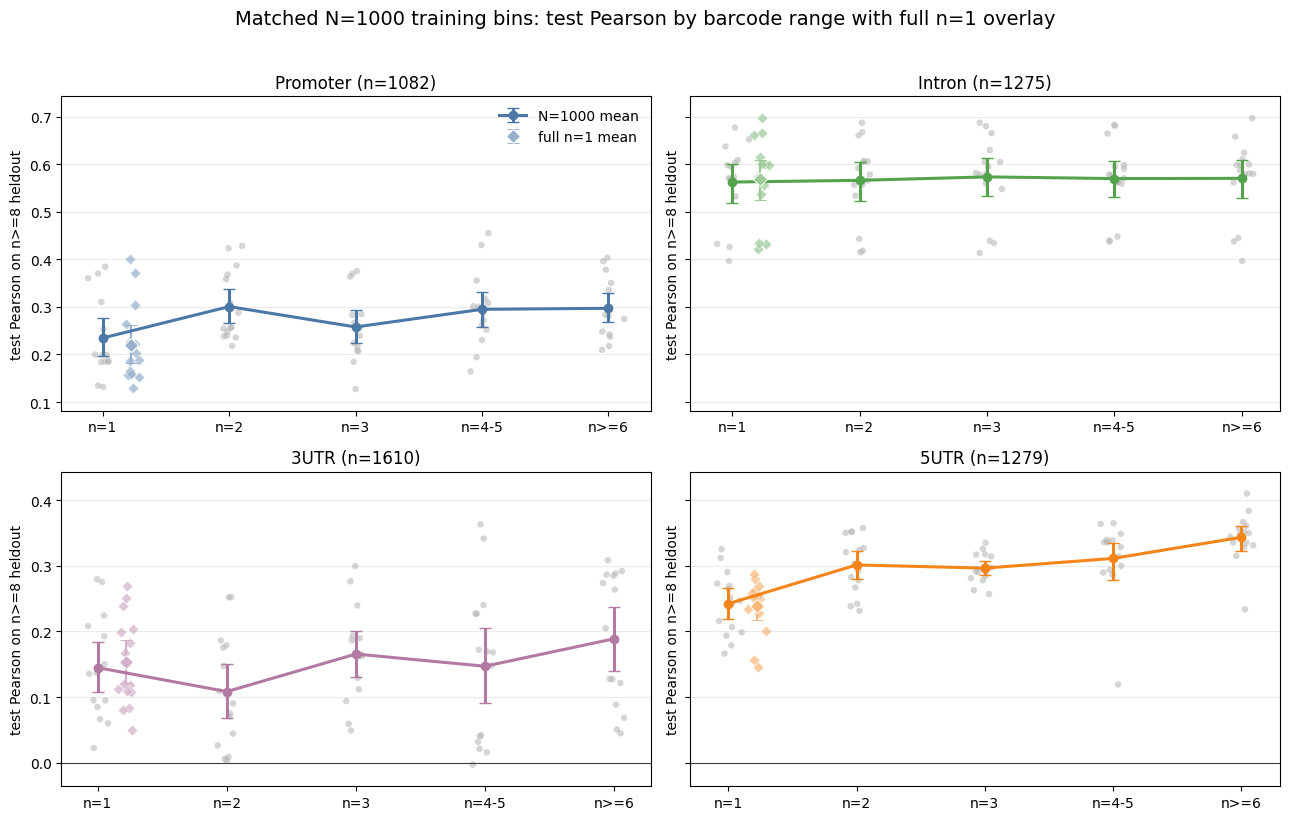

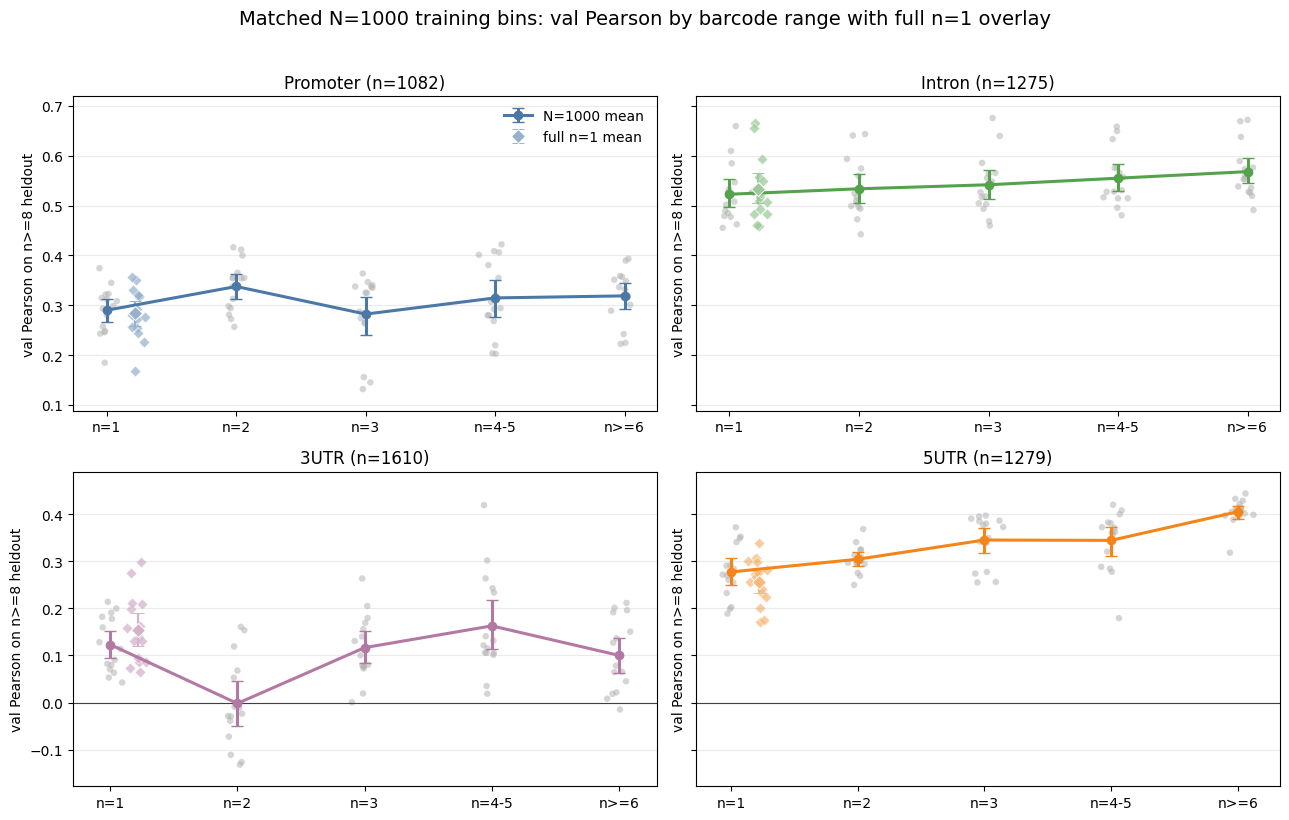

In [7]:
def lighten_color(color, amount=0.50):
    rgb = np.asarray(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb + (1.0 - rgb) * amount)


def _finite_extend(store, values):
    vals = np.asarray(values, dtype=float).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size:
        store.extend(vals.tolist())


def full_n1_title(part):
    if isinstance(n1_availability, pd.DataFrame) and not n1_availability.empty:
        s = n1_availability[n1_availability['part'].astype(str).eq(part)]
        if not s.empty and pd.notna(s['min_available_train_rows'].iloc[0]):
            return f"{part} (n={int(s['min_available_train_rows'].iloc[0])})"
    return part


def plot_matched_bin_metric(metric, metric_label, filename):
    mean_col = f'{metric}_mean'
    low_col = f'{metric}_ci_low'
    high_col = f'{metric}_ci_high'
    full_ready = (
        isinstance(full_n1_summary, pd.DataFrame)
        and not full_n1_summary.empty
        and mean_col in full_n1_summary.columns
        and full_n1_summary[mean_col].notna().any()
    )

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey='row')
    axes = axes.ravel()
    row_values = {0: [], 1: []}

    for panel_idx, (ax, part) in enumerate(zip(axes, PART_ORDER)):
        row_idx = panel_idx // 2
        g = df[df['part'].astype(str).eq(part)].copy()
        s = bin_summary[bin_summary['part'].astype(str).eq(part)].copy()
        x = np.arange(len(BIN_ORDER), dtype=float)
        rng = np.random.default_rng(stable_seed('jitter', metric, part, 20260616))
        for i, bin_id in enumerate(BIN_ORDER):
            vals = pd.to_numeric(g.loc[g['barcode_bin'].astype(str).eq(bin_id), metric], errors='coerce').dropna().to_numpy()
            jitter = rng.normal(0, 0.045, size=len(vals))
            ax.scatter(
                np.full(vals.size, i, dtype=float) + jitter,
                vals,
                s=22,
                color='0.70',
                alpha=0.55,
                edgecolor='none',
            )
            _finite_extend(row_values[row_idx], vals)

        means = s.set_index(s['barcode_bin'].astype(str)).loc[BIN_ORDER]
        y = means[mean_col].to_numpy(dtype=float)
        y_low = means[low_col].to_numpy(dtype=float)
        y_high = means[high_col].to_numpy(dtype=float)
        yerr = np.vstack([y - y_low, y_high - y])
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            color=PART_COLORS[part],
            marker='o',
            lw=2.2,
            capsize=4,
            label='N=1000 mean',
        )
        _finite_extend(row_values[row_idx], y_low)
        _finite_extend(row_values[row_idx], y_high)

        if full_ready:
            fs = full_n1_summary[full_n1_summary['part'].astype(str).eq(part)].copy()
            fg = full_n1_df[
                full_n1_df['part'].astype(str).eq(part)
                & full_n1_df['barcode_bin'].astype(str).eq('bc1')
            ].copy()
            if not fs.empty and fs[mean_col].notna().any():
                fs = fs.set_index(fs['barcode_bin'].astype(str))
                if 'bc1' in fs.index:
                    x_full = 0.22
                    full_color = lighten_color(PART_COLORS[part], 0.42)
                    raw_vals = pd.to_numeric(fg[metric], errors='coerce').dropna().to_numpy()
                    raw_jitter = rng.normal(0, 0.035, size=len(raw_vals))
                    ax.scatter(
                        np.full(raw_vals.size, x_full, dtype=float) + raw_jitter,
                        raw_vals,
                        s=30,
                        marker='D',
                        color=full_color,
                        alpha=0.72,
                        edgecolor='white',
                        linewidth=0.45,
                    )
                    y_full = float(fs.loc['bc1', mean_col])
                    lo_full = float(fs.loc['bc1', low_col])
                    hi_full = float(fs.loc['bc1', high_col])
                    ax.errorbar(
                        [x_full],
                        [y_full],
                        yerr=np.array([[y_full - lo_full], [hi_full - y_full]]),
                        color=full_color,
                        marker='D',
                        markersize=7,
                        lw=0,
                        elinewidth=1.6,
                        capsize=4,
                        markeredgecolor='white',
                        markeredgewidth=0.7,
                        label='full n=1 mean',
                    )
                    _finite_extend(row_values[row_idx], raw_vals)
                    _finite_extend(row_values[row_idx], [lo_full, hi_full])

        ax.set_title(full_n1_title(part))
        ax.set_xticks(x)
        ax.set_xticklabels([BIN_LABELS[b] for b in BIN_ORDER])
        ax.axhline(0, color='0.25', lw=0.8)
        ax.grid(axis='y', alpha=0.25)
        ax.set_ylabel(f'{metric_label} on n>=8 heldout')

    for row_idx in [0, 1]:
        vals = np.asarray(row_values[row_idx], dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            y_min, y_max = vals.min(), vals.max()
            pad = max(0.025, 0.08 * (y_max - y_min))
            for col_idx in [0, 1]:
                axes[row_idx * 2 + col_idx].set_ylim(y_min - pad, y_max + pad)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(frameon=False, loc='best')
    overlay_note = ' with full n=1 overlay' if full_ready else ''
    fig.suptitle(f'Matched N=1000 training bins: {metric_label} by barcode range{overlay_note}', y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig(ANALYSIS_DIR / filename, dpi=180, bbox_inches='tight')
    plt.show()


plot_matched_bin_metric('test_pearson', 'test Pearson', 'matched_n1000_test_pearson_by_bin.png')
plot_matched_bin_metric('val_pearson', 'val Pearson', 'matched_n1000_val_pearson_by_bin.png')


## Matched Delta Against The `n>=6` Bin

The table below is paired within the same `part x config x split_seed`. Negative means the lower barcode bin underperformed `n>=6`; positive means it beat `n>=6` for that matched slice.

In [8]:
delta_cols = [
    'part', 'barcode_bin_label', 'ref_bin_label', 'n_pairs',
    'delta_mean', 'delta_ci_low', 'delta_ci_high', 'delta_median', 'positive_fraction',
]
delta_display = test_delta_vs_ge6[delta_cols].copy()
for col in delta_display.select_dtypes(include=[float]).columns:
    delta_display[col] = delta_display[col].round(4)
display(delta_display)

,part,barcode_bin_label,ref_bin_label,n_pairs,delta_mean,delta_ci_low,delta_ci_high,delta_median,positive_fraction
0,Promoter,n=1,n>=6,15,-0.0624,-0.0904,-0.0365,-0.0554,0.0667
1,Promoter,n=2,n>=6,15,0.0036,-0.0163,0.0247,-0.0090,0.4667
2,Promoter,n=3,n>=6,15,-0.0393,-0.0599,-0.0205,-0.0285,0.1333
3,Promoter,n=4-5,n>=6,15,-0.0021,-0.0320,0.0283,0.0168,0.6000
4,Intron,n=1,n>=6,15,-0.0078,-0.0187,0.0029,-0.0071,0.2667
5,Intron,n=2,n>=6,15,-0.0042,-0.0148,0.0067,-0.0052,0.4000
6,Intron,n=3,n>=6,15,0.0031,-0.0073,0.0146,-0.0011,0.4667
7,Intron,n=4-5,n>=6,15,-0.0005,-0.0120,0.0124,-0.0079,0.2667
8,3UTR,n=1,n>=6,15,-0.0440,-0.0805,-0.0109,-0.0221,0.3333
9,3UTR,n=2,n>=6,15,-0.0804,-0.1116,-0.0490,-0.0837,0.1333


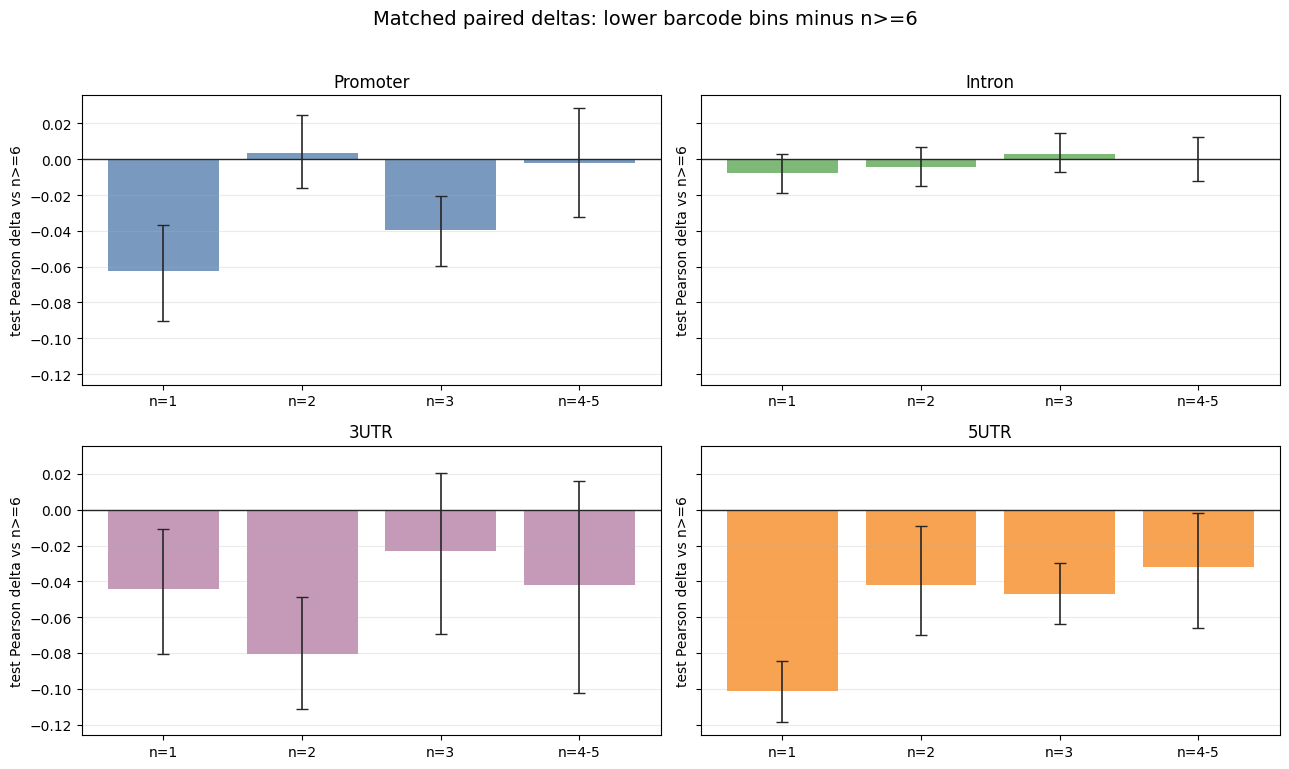

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey=True)
axes = axes.ravel()
for ax, part in zip(axes, PART_ORDER):
    g = test_delta_vs_ge6[test_delta_vs_ge6['part'].astype(str).eq(part)].copy()
    x = np.arange(len(g))
    y = g['delta_mean'].to_numpy()
    yerr = np.vstack([y - g['delta_ci_low'].to_numpy(), g['delta_ci_high'].to_numpy() - y])
    ax.bar(x, y, color=PART_COLORS[part], alpha=0.75)
    ax.errorbar(x, y, yerr=yerr, fmt='none', color='0.15', lw=1.2, capsize=4)
    ax.axhline(0, color='0.15', lw=1)
    ax.set_title(part)
    ax.set_xticks(x)
    ax.set_xticklabels(g['barcode_bin_label'])
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylabel('test Pearson delta vs n>=6')
fig.suptitle('Matched paired deltas: lower barcode bins minus n>=6', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'paired_test_delta_vs_ge6.png', dpi=180, bbox_inches='tight')
plt.show()

## Paired Tests For Barcode-Bin Differences

These tests are exploratory and paired by `part x config_id x split_seed`. The p-values test whether the matched mean delta differs from zero under sign-flips of the paired deltas. Use them as support for effect-size interpretation, not as a replacement for the effect sizes and CIs.


In [10]:
from itertools import product


def exact_signflip_pvalue(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return np.nan
    obs = abs(values.mean())
    if np.allclose(values, 0):
        return 1.0
    if n <= 20:
        means = []
        for signs in product([-1.0, 1.0], repeat=n):
            means.append(abs(np.dot(values, signs) / n))
        return float((np.asarray(means) >= obs - 1e-12).mean())
    rng = np.random.default_rng(20260617)
    signs = rng.choice([-1.0, 1.0], size=(200000, n), replace=True)
    means = np.abs(signs @ values / n)
    return float((means >= obs - 1e-12).mean())


def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    valid = np.isfinite(p)
    pv = p[valid]
    if len(pv) == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)
    q = ranked * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    valid_idx = np.where(valid)[0]
    out[valid_idx[order]] = q
    return out


def paired_delta_test_table(frame, metric='test_pearson', ref_bin='bc_ge6'):
    idx = ['part', 'config_id', 'split_seed']
    wide = frame.pivot_table(index=idx, columns='barcode_bin', values=metric, aggfunc='mean')
    rows = []
    for part in PART_ORDER:
        if part not in wide.index.get_level_values('part'):
            continue
        part_wide = wide.loc[part]
        for bin_id in [b for b in BIN_ORDER if b != ref_bin]:
            if bin_id not in part_wide.columns or ref_bin not in part_wide.columns:
                continue
            delta = (part_wide[bin_id] - part_wide[ref_bin]).dropna()
            lo, hi = bootstrap_mean_ci(delta, seed=stable_seed('paired-test', metric, part, bin_id, ref_bin))
            rows.append({
                'part': part,
                'metric': metric,
                'comparison': f'{BIN_LABELS[bin_id]} - {BIN_LABELS[ref_bin]}',
                'n_pairs': len(delta),
                'delta_mean': delta.mean(),
                'delta_median': delta.median(),
                'delta_ci_low': lo,
                'delta_ci_high': hi,
                'positive_fraction': (delta > 0).mean(),
                'signflip_p_two_sided': exact_signflip_pvalue(delta),
            })
    out = pd.DataFrame(rows)
    out['bh_fdr_q'] = bh_fdr(out['signflip_p_two_sided'])
    return out


def ordinal_trend_test_table(frame, metric='test_pearson'):
    # Treat bins as ordered categories rather than exact barcode counts.
    x = np.arange(len(BIN_ORDER), dtype=float)
    idx = ['part', 'config_id', 'split_seed']
    wide = frame.pivot_table(index=idx, columns='barcode_bin', values=metric, aggfunc='mean')
    rows = []
    slope_rows = []
    for key, row in wide.iterrows():
        if not all(bin_id in row.index and pd.notna(row[bin_id]) for bin_id in BIN_ORDER):
            continue
        y = row[BIN_ORDER].to_numpy(dtype=float)
        slope = np.polyfit(x, y, 1)[0]
        part, config_id, split_seed = key
        slope_rows.append({'part': part, 'config_id': config_id, 'split_seed': split_seed, 'ordinal_slope': slope})
    slopes = pd.DataFrame(slope_rows)
    for part, g in slopes.groupby('part', observed=True):
        lo, hi = bootstrap_mean_ci(g['ordinal_slope'], seed=stable_seed('trend', metric, part))
        rows.append({
            'part': part,
            'metric': metric,
            'n_slices': len(g),
            'ordinal_slope_mean': g['ordinal_slope'].mean(),
            'ordinal_slope_median': g['ordinal_slope'].median(),
            'ordinal_slope_ci_low': lo,
            'ordinal_slope_ci_high': hi,
            'positive_slope_fraction': (g['ordinal_slope'] > 0).mean(),
            'signflip_p_two_sided': exact_signflip_pvalue(g['ordinal_slope']),
        })
    out = pd.DataFrame(rows)
    out['bh_fdr_q'] = bh_fdr(out['signflip_p_two_sided'])
    return out, slopes

paired_test_table = paired_delta_test_table(df, metric='test_pearson', ref_bin='bc_ge6')
trend_test_table, trend_slices = ordinal_trend_test_table(df, metric='test_pearson')
paired_test_table.to_csv(ANALYSIS_DIR / 'paired_test_delta_vs_ge6_signflip_tests.csv', index=False)
trend_test_table.to_csv(ANALYSIS_DIR / 'ordinal_test_pearson_trend_tests.csv', index=False)
trend_slices.to_csv(ANALYSIS_DIR / 'ordinal_test_pearson_trend_slices.csv', index=False)

display(Markdown('**Pairwise paired tests versus `n>=6` on test Pearson**'))
display(paired_test_table.round(4))
display(Markdown('**Ordinal trend tests across barcode bins on test Pearson**'))
display(trend_test_table.round(4))

**Pairwise paired tests versus `n>=6` on test Pearson**

,part,metric,comparison,n_pairs,delta_mean,delta_median,delta_ci_low,delta_ci_high,positive_fraction,signflip_p_two_sided,bh_fdr_q
0,Promoter,test_pearson,n=1 - n>=6,15,-0.0624,-0.0554,-0.0898,-0.0356,0.0667,0.0007,0.0023
1,Promoter,test_pearson,n=2 - n>=6,15,0.0036,-0.0090,-0.0167,0.0243,0.4667,0.7413,0.8472
2,Promoter,test_pearson,n=3 - n>=6,15,-0.0393,-0.0285,-0.0599,-0.0206,0.1333,0.0006,0.0023
3,Promoter,test_pearson,n=4-5 - n>=6,15,-0.0021,0.0168,-0.0336,0.0272,0.6000,0.8990,0.9413
4,Intron,test_pearson,n=1 - n>=6,15,-0.0078,-0.0071,-0.0186,0.0033,0.2667,0.1976,0.3354
5,Intron,test_pearson,n=2 - n>=6,15,-0.0042,-0.0052,-0.0144,0.0069,0.4000,0.4618,0.6157
6,Intron,test_pearson,n=3 - n>=6,15,0.0031,-0.0011,-0.0074,0.0141,0.4667,0.6000,0.7384
7,Intron,test_pearson,n=4-5 - n>=6,15,-0.0005,-0.0079,-0.0117,0.0127,0.2667,0.9413,0.9413
8,3UTR,test_pearson,n=1 - n>=6,15,-0.0440,-0.0221,-0.0818,-0.0095,0.3333,0.0300,0.0685
9,3UTR,test_pearson,n=2 - n>=6,15,-0.0804,-0.0837,-0.1119,-0.0484,0.1333,0.0005,0.0023


**Ordinal trend tests across barcode bins on test Pearson**

,part,metric,n_slices,ordinal_slope_mean,ordinal_slope_median,ordinal_slope_ci_low,ordinal_slope_ci_high,positive_slope_fraction,signflip_p_two_sided,bh_fdr_q
0,3UTR,test_pearson,15,0.0127,0.0086,0.0045,0.0219,0.8000,0.0121,0.0161
1,5UTR,test_pearson,15,0.0212,0.0205,0.0177,0.0251,1.0000,0.0001,0.0002
2,Intron,test_pearson,15,0.0019,-0.0000,-0.0004,0.0044,0.4667,0.1520,0.1520
3,Promoter,test_pearson,15,0.0119,0.0115,0.0056,0.0182,0.7333,0.0042,0.0083


## Which Bin Wins Within Matched Slices?

Mean performance can hide instability. This asks how often each bin is the best test-Pearson bin for the same config and split seed.

,part,barcode_bin,barcode_bin_label,n,winner_fraction,median_rank,mean_rank
0,Promoter,bc1,n=1,15,0.0667,5.0,4.4000
1,Promoter,bc2,n=2,15,0.2667,2.0,2.2667
2,Promoter,bc3,n=3,15,0.0000,4.0,3.8000
3,Promoter,bc4_5,n=4-5,15,0.4000,2.0,2.2667
4,Promoter,bc_ge6,n>=6,15,0.2667,2.0,2.2667
5,Intron,bc1,n=1,15,0.0000,4.0,3.7333
6,Intron,bc2,n=2,15,0.1333,3.0,3.0667
7,Intron,bc3,n=3,15,0.2667,3.0,2.6667
8,Intron,bc4_5,n=4-5,15,0.2000,3.0,3.1333
9,Intron,bc_ge6,n>=6,15,0.4000,2.0,2.4000


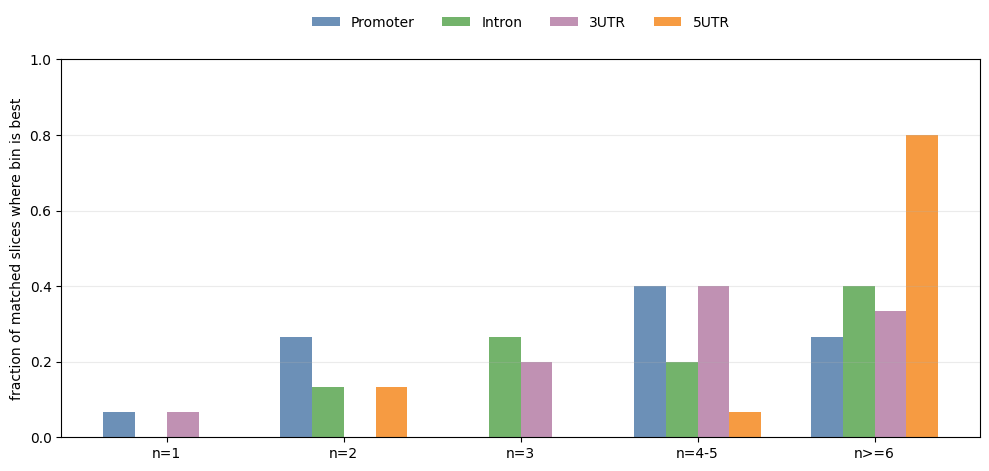

In [11]:
win_display = test_winner_rates.copy()
for col in win_display.select_dtypes(include=[float]).columns:
    win_display[col] = win_display[col].round(4)
display(win_display)

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_rows = []
for part in PART_ORDER:
    g = test_winner_rates[test_winner_rates['part'].astype(str).eq(part)]
    for _, row in g.iterrows():
        plot_rows.append(row)
plot_df = pd.DataFrame(plot_rows)

width = 0.18
x = np.arange(len(BIN_ORDER))
for j, part in enumerate(PART_ORDER):
    pg = plot_df[plot_df['part'].astype(str).eq(part)]
    g = pg.set_index(pg['barcode_bin'].astype(str)).loc[BIN_ORDER]
    ax.bar(x + (j - 1.5) * width, g['winner_fraction'], width=width, label=part, color=PART_COLORS[part], alpha=0.82)
ax.set_xticks(x)
ax.set_xticklabels([BIN_LABELS[b] for b in BIN_ORDER])
ax.set_ylabel('fraction of matched slices where bin is best')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.15))
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'test_winner_fraction_by_bin.png', dpi=180, bbox_inches='tight')
plt.show()

## Train Fit Versus Heldout Generalization

If a bin contains mostly noise, we expect weak train fit and/or weak heldout transfer. If it contains real signal but lower label precision, it may show positive heldout transfer but lower performance than high-barcode training.

,part,barcode_bin_label,train_pearson_mean,test_pearson_mean,generalization_gap_train_test_mean,generalization_gap_train_test_ci_low,generalization_gap_train_test_ci_high,best_epoch_median
0,Promoter,n=1,0.4037,0.2346,0.1691,0.1192,0.2203,77.0
1,Promoter,n=2,0.4002,0.3006,0.0996,0.0503,0.1450,58.0
2,Promoter,n=3,0.4186,0.2578,0.1608,0.0735,0.2692,44.0
3,Promoter,n=4-5,0.4464,0.2950,0.1514,0.0984,0.2019,42.0
4,Promoter,n>=6,0.4627,0.2971,0.1657,0.1018,0.2299,68.0
5,Intron,n=1,0.4047,0.5626,-0.1578,-0.2003,-0.1138,54.0
6,Intron,n=2,0.4490,0.5662,-0.1172,-0.1623,-0.0717,59.0
7,Intron,n=3,0.4875,0.5735,-0.0859,-0.1251,-0.0436,38.0
8,Intron,n=4-5,0.5616,0.5699,-0.0083,-0.0672,0.0591,40.0
9,Intron,n>=6,0.6214,0.5704,0.0511,0.0051,0.0988,85.0


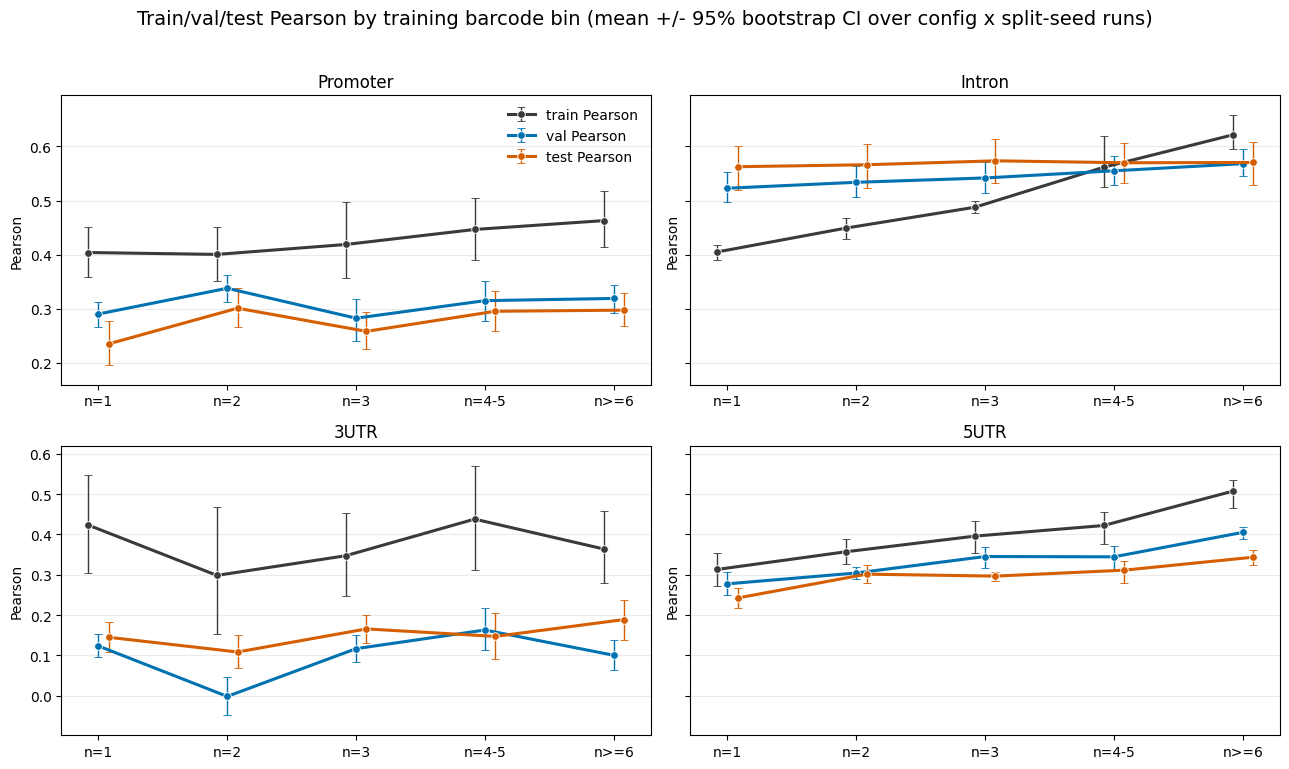

In [12]:
gap_cols = [
    'part', 'barcode_bin_label', 'train_pearson_mean', 'test_pearson_mean',
    'generalization_gap_train_test_mean', 'generalization_gap_train_test_ci_low', 'generalization_gap_train_test_ci_high',
    'best_epoch_median',
]
gap_display = bin_summary[gap_cols].copy()
for col in gap_display.select_dtypes(include=[float]).columns:
    gap_display[col] = gap_display[col].round(4)
display(gap_display)

METRIC_COLORS = {
    'train': '#3A3A3A',  # dark neutral
    'val': '#0072B2',    # high-contrast blue
    'test': '#D55E00',   # high-contrast orange
}
METRIC_SPECS = [
    ('train', 'train_pearson_mean', 'train_pearson_ci_low', 'train_pearson_ci_high', -0.08, 'train Pearson'),
    ('val', 'val_pearson_mean', 'val_pearson_ci_low', 'val_pearson_ci_high', 0.00, 'val Pearson'),
    ('test', 'test_pearson_mean', 'test_pearson_ci_low', 'test_pearson_ci_high', 0.08, 'test Pearson'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey='row')
axes = axes.ravel()
for ax, part in zip(axes, PART_ORDER):
    ps = bin_summary[bin_summary['part'].astype(str).eq(part)]
    s = ps.set_index(ps['barcode_bin'].astype(str)).loc[BIN_ORDER]
    x = np.arange(len(BIN_ORDER), dtype=float)
    for key, mean_col, low_col, high_col, offset, label in METRIC_SPECS:
        y = s[mean_col].to_numpy(dtype=float)
        yerr = np.vstack([
            y - s[low_col].to_numpy(dtype=float),
            s[high_col].to_numpy(dtype=float) - y,
        ])
        ax.errorbar(
            x + offset,
            y,
            yerr=yerr,
            marker='o',
            markersize=5.5,
            markeredgecolor='white',
            markeredgewidth=0.6,
            lw=2.2,
            elinewidth=1.0,
            capsize=3,
            label=label,
            color=METRIC_COLORS[key],
        )
    ax.set_title(part)
    ax.set_xticks(x)
    ax.set_xticklabels([BIN_LABELS[b] for b in BIN_ORDER])
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylabel('Pearson')

# Keep panels in each row on the same y-scale while allowing rows to differ.
row_parts = [PART_ORDER[:2], PART_ORDER[2:]]
for row_idx, parts in enumerate(row_parts):
    row_lows = []
    row_highs = []
    for part in parts:
        ps = bin_summary[bin_summary['part'].astype(str).eq(part)]
        for _, _, low_col, high_col, _, _ in METRIC_SPECS:
            row_lows.extend(ps[low_col].to_numpy(dtype=float).ravel())
            row_highs.extend(ps[high_col].to_numpy(dtype=float).ravel())
    row_lows = np.asarray(row_lows)
    row_highs = np.asarray(row_highs)
    row_lows = row_lows[np.isfinite(row_lows)]
    row_highs = row_highs[np.isfinite(row_highs)]
    y_min, y_max = row_lows.min(), row_highs.max()
    pad = max(0.025, 0.08 * (y_max - y_min))
    for col_idx in range(2):
        axes[row_idx * 2 + col_idx].set_ylim(y_min - pad, y_max + pad)

axes[0].legend(frameon=False)
fig.suptitle('Train/val/test Pearson by training barcode bin (mean +/- 95% bootstrap CI over config x split-seed runs)', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'train_val_test_pearson_by_bin.png', dpi=180, bbox_inches='tight')
plt.show()

### Uncertainty Note For Bin Plots

The bootstrap CIs above are bootstrap confidence intervals for the mean across the 15 completed runs in each `part x barcode_bin` group: 3 configs x 5 split seeds. They are not raw per-variant uncertainty, and they are not only split-seed variation. For seed-only uncertainty, aggregate configs within each split seed first, then compute SEM/CI across the five split seeds.


## Config And Split Robustness

These views check whether a barcode-bin conclusion is carried by one lucky config or split seed.

In [13]:
def sem(values):
    values = pd.to_numeric(values, errors='coerce').dropna()
    if len(values) <= 1:
        return np.nan
    return values.std(ddof=1) / np.sqrt(len(values))

config_bin_summary = (
    df.groupby(['part', 'config_id', 'barcode_bin', 'barcode_bin_label'], observed=True)
    .agg(
        n=('run_name', 'size'),
        val_pearson_mean=('val_pearson', 'mean'),
        test_pearson_mean=('test_pearson', 'mean'),
        test_pearson_std=('test_pearson', 'std'),
        test_pearson_sem=('test_pearson', sem),
    )
    .reset_index()
)
config_bin_summary['part'] = pd.Categorical(config_bin_summary['part'], PART_ORDER, ordered=True)
config_bin_summary['barcode_bin'] = pd.Categorical(config_bin_summary['barcode_bin'], BIN_ORDER, ordered=True)
config_bin_summary = config_bin_summary.sort_values(['part', 'config_id', 'barcode_bin'])
config_bin_summary.to_csv(ANALYSIS_DIR / 'config_bin_summary.csv', index=False)

display(config_bin_summary.round(4))

split_seed_summary = (
    df.groupby(['part', 'split_seed', 'barcode_bin', 'barcode_bin_label'], observed=True)
    .agg(
        n=('run_name', 'size'),
        test_pearson_mean=('test_pearson', 'mean'),
        test_pearson_std=('test_pearson', 'std'),
    )
    .reset_index()
)
split_seed_summary.to_csv(ANALYSIS_DIR / 'split_seed_bin_summary.csv', index=False)

,part,config_id,barcode_bin,barcode_bin_label,n,val_pearson_mean,test_pearson_mean,test_pearson_std,test_pearson_sem
0,Promoter,promoter_cfg011,bc1,n=1,5,0.2969,0.2420,0.1029,0.0460
1,Promoter,promoter_cfg011,bc2,n=2,5,0.3260,0.2774,0.0856,0.0383
2,Promoter,promoter_cfg011,bc3,n=3,5,0.2896,0.2641,0.0605,0.0270
3,Promoter,promoter_cfg011,bc4_5,n=4-5,5,0.3084,0.2367,0.0564,0.0252
4,Promoter,promoter_cfg011,bc_ge6,n>=6,5,0.3336,0.2873,0.0724,0.0324
5,Promoter,promoter_cfg018,bc1,n=1,5,0.2740,0.2326,0.0800,0.0358
6,Promoter,promoter_cfg018,bc2,n=2,5,0.3394,0.3222,0.0732,0.0327
7,Promoter,promoter_cfg018,bc3,n=3,5,0.2809,0.2411,0.0931,0.0416
8,Promoter,promoter_cfg018,bc4_5,n=4-5,5,0.3209,0.3319,0.0770,0.0344
9,Promoter,promoter_cfg018,bc_ge6,n>=6,5,0.3223,0.3080,0.0517,0.0231


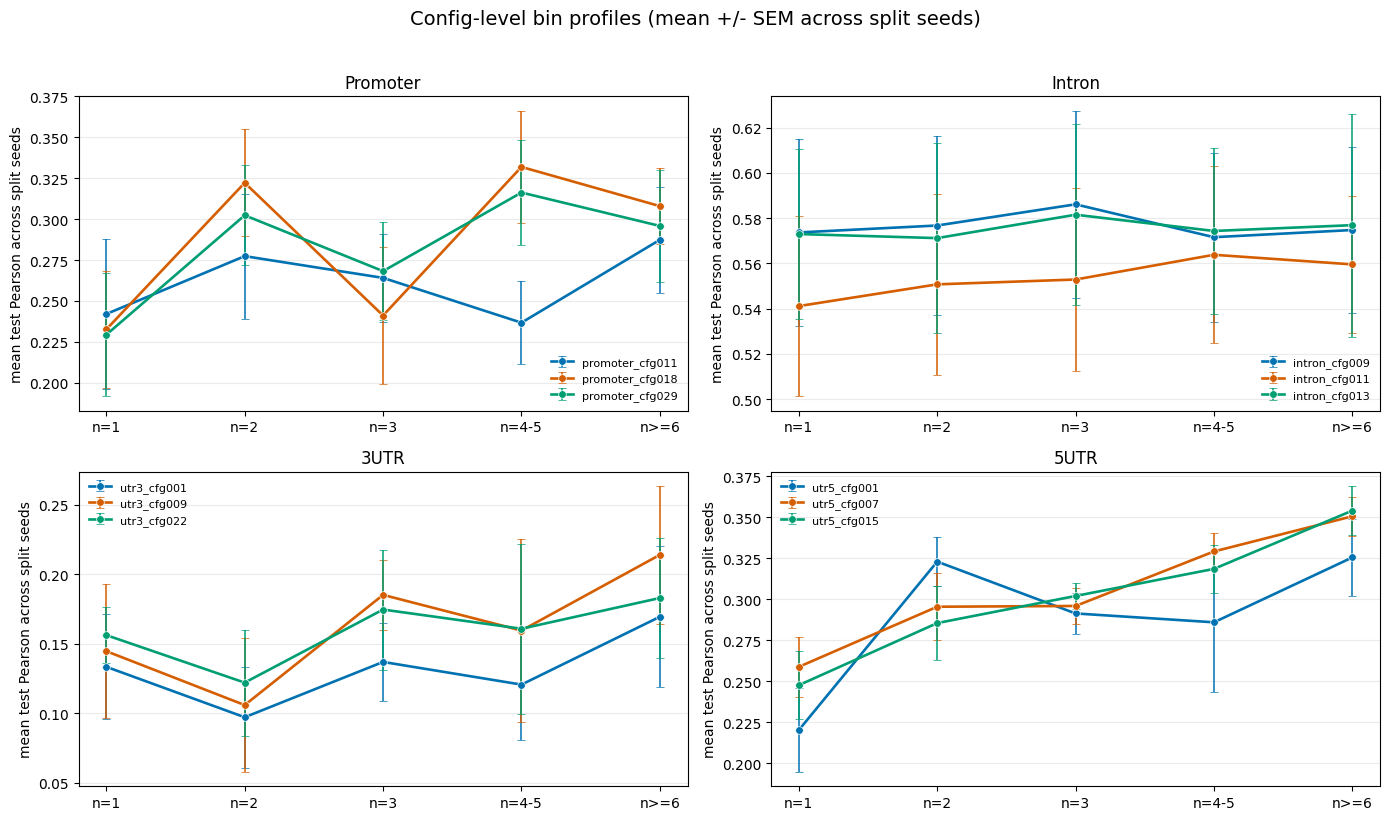

In [14]:
CONFIG_PROFILE_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.ravel()
for ax, part in zip(axes, PART_ORDER):
    g = config_bin_summary[config_bin_summary['part'].astype(str).eq(part)].copy()
    for color, (config_id, cg) in zip(CONFIG_PROFILE_COLORS, g.groupby('config_id', observed=True, sort=False)):
        cg = cg.set_index(cg['barcode_bin'].astype(str)).loc[BIN_ORDER]
        x = np.arange(len(BIN_ORDER))
        y = cg['test_pearson_mean'].to_numpy(dtype=float)
        yerr = cg['test_pearson_sem'].fillna(0).to_numpy(dtype=float)
        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker='o',
            markersize=5.5,
            markeredgecolor='white',
            markeredgewidth=0.5,
            lw=1.9,
            elinewidth=1.1,
            capsize=3,
            color=color,
            label=config_id,
        )
    ax.set_title(part)
    ax.set_xticks(np.arange(len(BIN_ORDER)))
    ax.set_xticklabels([BIN_LABELS[b] for b in BIN_ORDER])
    ax.set_ylabel('mean test Pearson across split seeds')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Config-level bin profiles (mean +/- SEM across split seeds)', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / 'config_level_bin_profiles.png', dpi=180, bbox_inches='tight')
plt.show()

## Weighted Full-Training Context

The matched-bin experiment above answers the barcode-range signal question. The previous weighted-loss follow-up answers a different question: whether changing the training loss on the full eligible training set improves heldout performance. Keeping these separate avoids varying barcode composition and loss weighting at the same time.

In [15]:
weighted_overall_path = WEIGHTED_ANALYSIS_DIR / 'paired_weighted_vs_unweighted_overall_summary.csv'
weighted_part_path = WEIGHTED_ANALYSIS_DIR / 'paired_weighted_vs_unweighted_part_summary.csv'
weighted_bootstrap_path = WEIGHTED_ANALYSIS_DIR / 'paired_delta_bootstrap_summary.csv'

if weighted_overall_path.exists() and weighted_part_path.exists():
    weighted_overall = pd.read_csv(weighted_overall_path)
    weighted_part = pd.read_csv(weighted_part_path)
    display(Markdown('**Overall weighted vs unweighted full-training paired result**'))
    display(weighted_overall.round(4))
    display(Markdown('**By part**'))
    keep = [
        'part', 'n',
        'val_pearson_weighted_mean', 'val_pearson_unweighted_mean', 'delta_val_pearson_mean',
        'test_pearson_weighted_mean', 'test_pearson_unweighted_mean', 'delta_test_pearson_mean',
        'train_pearson_weighted_mean', 'train_pearson_unweighted_mean', 'delta_train_pearson_mean',
        'test_pearson_weighted_better_n',
    ]
    keep = [c for c in keep if c in weighted_part.columns]
    display(weighted_part[keep].round(4))
else:
    display(Markdown('Weighted-loss summary CSVs were not found; skipping this context section.'))

**Overall weighted vs unweighted full-training paired result**

,metric,weighted_mean,unweighted_mean,delta_mean,delta_median,delta_std,delta_min,delta_max,weighted_better_n,n
0,val_pearson,0.4794,0.4752,0.0042,0.0008,0.0263,-0.0772,0.0942,33,60
1,test_pearson,0.4606,0.4590,0.0016,0.0052,0.0301,-0.1373,0.0557,37,60
2,train_pearson,0.4791,0.5002,-0.0210,-0.0119,0.1061,-0.3346,0.3762,16,60
3,val_mse,0.4696,0.4829,-0.0133,-0.0068,0.0327,-0.1271,0.0703,37,60
4,test_mse,0.4818,0.4889,-0.0071,-0.0054,0.0236,-0.0659,0.0717,42,60
5,val_cod_r2,0.1981,0.1776,0.0205,0.0158,0.0468,-0.0967,0.1605,37,60
6,test_cod_r2,0.1848,0.1711,0.0137,0.0111,0.0382,-0.1123,0.1075,42,60
7,best_epoch,106.7167,111.0667,-4.3500,0.0000,35.4271,-83.0000,83.0000,27,60


**By part**

,part,n,val_pearson_weighted_mean,val_pearson_unweighted_mean,delta_val_pearson_mean,test_pearson_weighted_mean,test_pearson_unweighted_mean,delta_test_pearson_mean,train_pearson_weighted_mean,train_pearson_unweighted_mean,delta_train_pearson_mean,test_pearson_weighted_better_n
0,3UTR,15,0.3618,0.3532,0.0086,0.3554,0.3677,-0.0123,0.4679,0.5089,-0.0411,7
1,5UTR,15,0.4943,0.4900,0.0043,0.4299,0.4211,0.0089,0.4141,0.4281,-0.0141,12
2,Intron,15,0.6102,0.6038,0.0064,0.6182,0.6141,0.0042,0.5685,0.5629,0.0056,9
3,Promoter,15,0.4512,0.4538,-0.0026,0.4387,0.4332,0.0055,0.4662,0.5008,-0.0346,9


### Weighted-Loss Plots

These figures convert the weighted-loss summary tables into paired visual readouts. The plotted value is `weighted - unweighted` for the same `(part, config_id, split_seed)`. Error bars summarize split-seed variation by first averaging the three configs within each split seed, then computing SEM across the five split seeds.


**Follow-up fit accounting**

,stage,new_fits_launched,parts,configs_per_part,split_seeds,training_pools_or_loss_arms,note
0,Stage 1 full-pool weighted comparison,60,4,3,5,1,60 new weighted fits; paired against 60 reused...
1,Stage 2 barcode-bin matched-N intervention,300,4,3,5,5,300 unweighted fits: 4 parts x 3 configs x 5 s...


**Heldout weighted-minus-unweighted deltas by part**

,part,metric,metric_label,delta_mean,delta_sem,delta_std,n_split_seeds
6,Promoter,test_pearson,test Pearson,0.0055,0.0084,0.0189,5
7,Promoter,val_pearson,val Pearson,-0.0026,0.0059,0.0133,5
4,Intron,test_pearson,test Pearson,0.0042,0.0028,0.0062,5
5,Intron,val_pearson,val Pearson,0.0064,0.0046,0.0102,5
0,3UTR,test_pearson,test Pearson,-0.0123,0.0100,0.0223,5
1,3UTR,val_pearson,val Pearson,0.0086,0.0142,0.0318,5
2,5UTR,test_pearson,test Pearson,0.0089,0.0030,0.0067,5
3,5UTR,val_pearson,val Pearson,0.0043,0.0024,0.0055,5


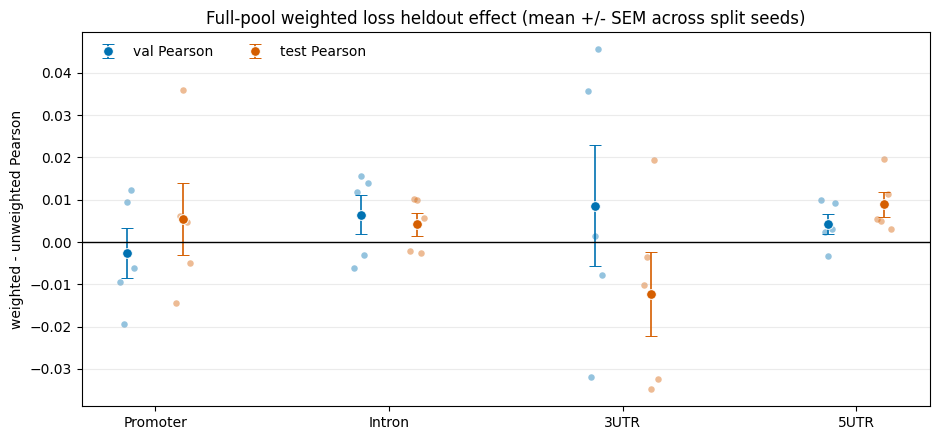

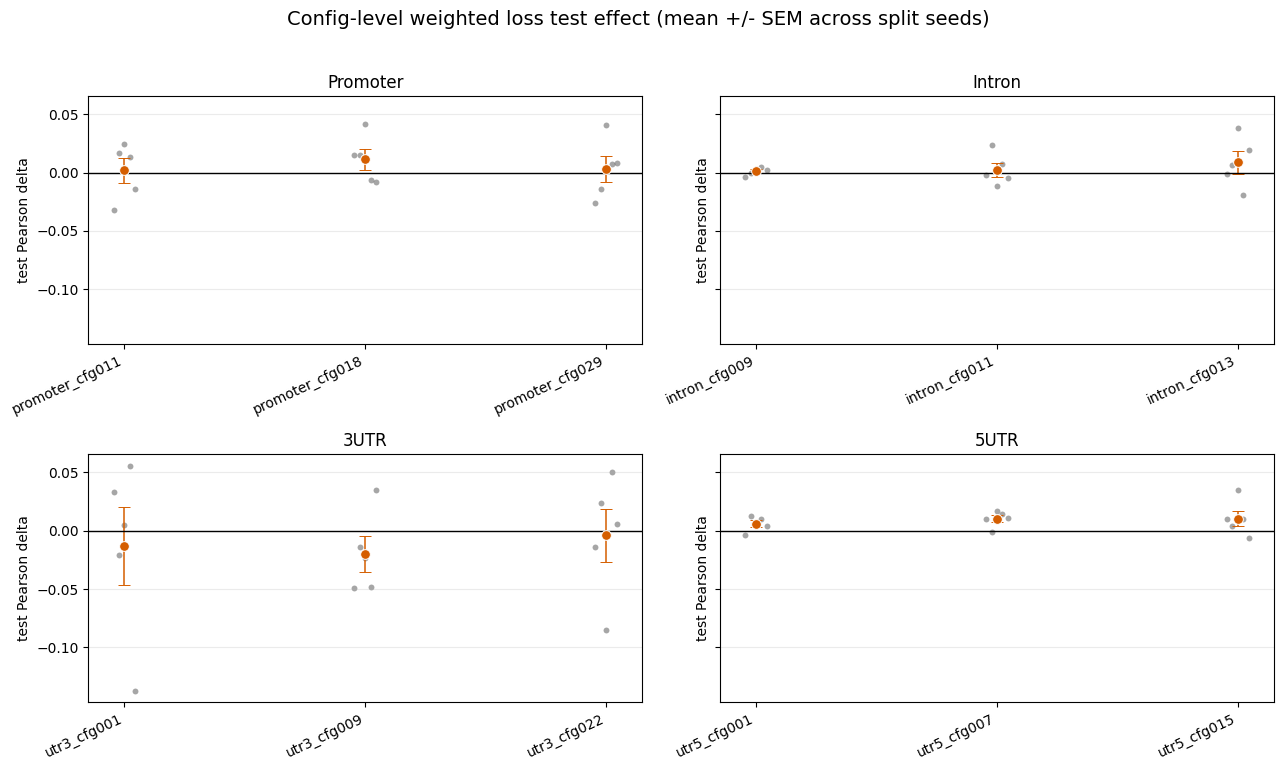

In [16]:
weighted_runs_path = WEIGHTED_ANALYSIS_DIR / 'paired_weighted_vs_unweighted_runs.csv'

if weighted_runs_path.exists():
    weighted_runs = pd.read_csv(weighted_runs_path)
    weighted_fit_accounting = pd.DataFrame([
        {
            'stage': 'Stage 1 full-pool weighted comparison',
            'new_fits_launched': len(weighted_runs),
            'parts': weighted_runs['part'].nunique(),
            'configs_per_part': int(weighted_runs.groupby('part')['config_id'].nunique().median()),
            'split_seeds': weighted_runs['split_seed'].nunique(),
            'training_pools_or_loss_arms': 1,
            'note': '60 new weighted fits; paired against 60 reused unweighted outer-seed baselines.',
        },
        {
            'stage': 'Stage 2 barcode-bin matched-N intervention',
            'new_fits_launched': len(df),
            'parts': df['part'].nunique(),
            'configs_per_part': int(df.groupby('part')['config_id'].nunique().median()),
            'split_seeds': df['split_seed'].nunique(),
            'training_pools_or_loss_arms': df['barcode_bin'].nunique(),
            'note': '300 unweighted fits: 4 parts x 3 configs x 5 split seeds x 5 barcode bins.',
        },
    ])
    display(Markdown('**Follow-up fit accounting**'))
    display(weighted_fit_accounting)

    def _sem(values):
        vals = pd.to_numeric(pd.Series(values), errors='coerce').dropna()
        if len(vals) <= 1:
            return np.nan
        return float(vals.std(ddof=1) / np.sqrt(len(vals)))

    weighted_metric_specs = [
        ('val_pearson', 'val Pearson', '#0072B2', -0.12),
        ('test_pearson', 'test Pearson', '#D55E00', 0.12),
    ]
    weighted_delta_records = []
    for metric, label, color, offset in weighted_metric_specs:
        delta_col = f'delta_{metric}'
        if delta_col not in weighted_runs.columns:
            continue
        tmp = weighted_runs[['part', 'config_id', 'split_seed', delta_col]].copy()
        tmp = tmp.rename(columns={delta_col: 'delta'})
        tmp['metric'] = metric
        tmp['metric_label'] = label
        tmp['color'] = color
        tmp['offset'] = offset
        weighted_delta_records.append(tmp)

    weighted_delta_long = pd.concat(weighted_delta_records, ignore_index=True)
    weighted_delta_seed = (
        weighted_delta_long.groupby(['part', 'split_seed', 'metric', 'metric_label'], observed=True)
        .agg(delta=('delta', 'mean'))
        .reset_index()
    )
    weighted_delta_seed_summary = (
        weighted_delta_seed.groupby(['part', 'metric', 'metric_label'], observed=True)
        .agg(
            delta_mean=('delta', 'mean'),
            delta_sem=('delta', _sem),
            delta_std=('delta', 'std'),
            n_split_seeds=('split_seed', 'nunique'),
        )
        .reset_index()
    )
    weighted_delta_seed_summary['part'] = pd.Categorical(weighted_delta_seed_summary['part'], PART_ORDER, ordered=True)
    weighted_delta_seed_summary = weighted_delta_seed_summary.sort_values(['part', 'metric'])
    display(Markdown('**Heldout weighted-minus-unweighted deltas by part**'))
    display(weighted_delta_seed_summary.round(4))
    weighted_delta_seed_summary.to_csv(ANALYSIS_DIR / 'weighted_loss_heldout_delta_by_part_seed_summary.csv', index=False)

    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    x = np.arange(len(PART_ORDER), dtype=float)
    for metric, label, color, offset in weighted_metric_specs:
        s = weighted_delta_seed_summary[weighted_delta_seed_summary['metric'].eq(metric)].set_index('part').reindex(PART_ORDER)
        ax.errorbar(
            x + offset,
            s['delta_mean'].to_numpy(dtype=float),
            yerr=s['delta_sem'].to_numpy(dtype=float),
            marker='o',
            lw=0,
            elinewidth=1.2,
            capsize=4,
            markersize=7,
            markeredgecolor='white',
            markeredgewidth=0.7,
            label=label,
            color=color,
        )
        for part_idx, part in enumerate(PART_ORDER):
            vals = weighted_delta_seed[
                weighted_delta_seed['part'].astype(str).eq(part) & weighted_delta_seed['metric'].eq(metric)
            ]['delta'].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                jitter = np.linspace(-0.03, 0.03, vals.size) if vals.size > 1 else np.array([0.0])
                ax.scatter(np.full(vals.size, x[part_idx] + offset) + jitter, vals, s=22, color=color, alpha=0.42, linewidths=0)
    ax.axhline(0, color='black', lw=1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(PART_ORDER)
    ax.set_ylabel('weighted - unweighted Pearson')
    ax.set_title('Full-pool weighted loss heldout effect (mean +/- SEM across split seeds)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, ncol=2, loc='upper left')
    fig.tight_layout()
    fig.savefig(ANALYSIS_DIR / 'weighted_loss_heldout_delta_by_part_seed_sem.png', dpi=180, bbox_inches='tight')
    plt.show()

    test_config_seed = weighted_delta_long[weighted_delta_long['metric'].eq('test_pearson')].copy()
    weighted_config_summary = (
        test_config_seed.groupby(['part', 'config_id'], observed=True)
        .agg(
            delta_mean=('delta', 'mean'),
            delta_sem=('delta', _sem),
            delta_std=('delta', 'std'),
            n_split_seeds=('split_seed', 'nunique'),
        )
        .reset_index()
    )
    weighted_config_summary['part'] = pd.Categorical(weighted_config_summary['part'], PART_ORDER, ordered=True)
    weighted_config_summary = weighted_config_summary.sort_values(['part', 'config_id'])
    weighted_config_summary.to_csv(ANALYSIS_DIR / 'weighted_loss_config_test_delta_seed_summary.csv', index=False)

    fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey=True)
    axes = axes.ravel()
    for ax, part in zip(axes, PART_ORDER):
        s = weighted_config_summary[weighted_config_summary['part'].astype(str).eq(part)].sort_values('config_id')
        xcfg = np.arange(len(s), dtype=float)
        ax.errorbar(
            xcfg,
            s['delta_mean'].to_numpy(dtype=float),
            yerr=s['delta_sem'].fillna(0).to_numpy(dtype=float),
            marker='o',
            lw=0,
            elinewidth=1.1,
            capsize=4,
            markersize=7,
            color='#D55E00',
            markeredgecolor='white',
            markeredgewidth=0.7,
        )
        for i, cfg in enumerate(s['config_id']):
            vals = test_config_seed[
                test_config_seed['part'].astype(str).eq(part) & test_config_seed['config_id'].eq(cfg)
            ]['delta'].to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                jitter = np.linspace(-0.045, 0.045, vals.size) if vals.size > 1 else np.array([0.0])
                ax.scatter(np.full(vals.size, i) + jitter, vals, s=18, color='#3A3A3A', alpha=0.45, linewidths=0)
        ax.axhline(0, color='black', lw=1.0)
        ax.set_title(part)
        ax.set_xticks(xcfg)
        ax.set_xticklabels(s['config_id'], rotation=25, ha='right')
        ax.grid(axis='y', alpha=0.25)
        ax.set_ylabel('test Pearson delta')
    fig.suptitle('Config-level weighted loss test effect (mean +/- SEM across split seeds)', y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig(ANALYSIS_DIR / 'weighted_loss_config_test_delta_seed_sem.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    display(Markdown('Weighted paired-run CSV was not found; skipping weighted-loss plots.'))


## Answer Table

This section converts the numeric tables into the original decision questions. The labels are intentionally conservative: this experiment is strong for bin-specific transfer signal, weaker for causal claims about barcode count alone, and not a direct weighted-loss rescue test.

In [17]:
answer_rows = []

# Question 1: weighting on full set, from prior paired run.
if weighted_overall_path.exists():
    wo = pd.read_csv(weighted_overall_path).set_index('metric')
    if 'test_pearson' in wo.index:
        d = float(wo.loc['test_pearson', 'delta_mean'])
        n_better = int(wo.loc['test_pearson', 'weighted_better_n'])
        n_total = int(wo.loc['test_pearson', 'n'])
        strength = 'small positive / not decisive' if abs(d) < 0.01 else ('positive' if d > 0 else 'negative')
        answer_rows.append({
            'question': 'Does weighting improve full-training performance?',
            'current evidence': strength,
            'key measurement': f'paired full-training test Pearson delta = {d:+.4f}; weighted better in {n_better}/{n_total} runs',
            'interpretation boundary': 'This uses full eligible training pools, not isolated bins.',
        })

# Question 2: low barcode bins.
for part in PART_ORDER:
    ps = bin_summary[bin_summary['part'].astype(str).eq(part)]
    s = ps.set_index(ps['barcode_bin'].astype(str))
    bc1 = float(s.loc['bc1', 'test_pearson_mean'])
    ge6 = float(s.loc['bc_ge6', 'test_pearson_mean'])
    frac = bc1 / ge6 if ge6 != 0 else np.nan
    best_bin = s['test_pearson_mean'].idxmax()
    answer_rows.append({
        'question': f'Do n=1 variants add useful transferable signal? ({part})',
        'current evidence': 'yes, but weaker than high-bc' if bc1 > 0 and frac < 0.9 else ('yes, near high-bc' if bc1 > 0 else 'not supported'),
        'key measurement': f'n=1 mean test Pearson = {bc1:.3f}; n>=6 = {ge6:.3f}; n=1 retains {frac:.0%} of n>=6 mean; best bin = {BIN_LABELS.get(best_bin, best_bin)}',
        'interpretation boundary': 'Matched N=1000; heldout is n>=8. This measures transfer to high-confidence heldout variants.',
    })

answer_rows.append({
    'question': 'Does weighting rescue low-barcode variants?',
    'current evidence': 'not directly tested here',
    'key measurement': 'The bin run is unweighted by design; the weighted full-training run showed only a small overall heldout gain.',
    'interpretation boundary': 'A direct rescue test would compare weighted vs unweighted inside mixed low/high pools, or use additive HQ+low-bin designs.',
})

answers = pd.DataFrame(answer_rows)
display(answers)
answers.to_csv(ANALYSIS_DIR / 'objective_answer_table.csv', index=False)

,question,current evidence,key measurement,interpretation boundary
0,Does weighting improve full-training performance?,small positive / not decisive,paired full-training test Pearson delta = +0.0...,"This uses full eligible training pools, not is..."
1,Do n=1 variants add useful transferable signal...,"yes, but weaker than high-bc",n=1 mean test Pearson = 0.235; n>=6 = 0.297; n...,Matched N=1000; heldout is n>=8. This measures...
2,Do n=1 variants add useful transferable signal...,"yes, near high-bc",n=1 mean test Pearson = 0.563; n>=6 = 0.570; n...,Matched N=1000; heldout is n>=8. This measures...
3,Do n=1 variants add useful transferable signal...,"yes, but weaker than high-bc",n=1 mean test Pearson = 0.145; n>=6 = 0.189; n...,Matched N=1000; heldout is n>=8. This measures...
4,Do n=1 variants add useful transferable signal...,"yes, but weaker than high-bc",n=1 mean test Pearson = 0.242; n>=6 = 0.343; n...,Matched N=1000; heldout is n>=8. This measures...
5,Does weighting rescue low-barcode variants?,not directly tested here,The bin run is unweighted by design; the weigh...,A direct rescue test would compare weighted vs...


In [18]:
def narrate_part(part):
    ps = bin_summary[bin_summary['part'].astype(str).eq(part)]
    s = ps.set_index(ps['barcode_bin'].astype(str))
    best_bin = s['test_pearson_mean'].idxmax()
    worst_bin = s['test_pearson_mean'].idxmin()
    ge6 = float(s.loc['bc_ge6', 'test_pearson_mean'])
    bc1 = float(s.loc['bc1', 'test_pearson_mean'])
    bc2 = float(s.loc['bc2', 'test_pearson_mean'])
    monotone = s.loc[BIN_ORDER, 'test_pearson_mean'].is_monotonic_increasing
    return (
        f'- **{part}:** best mean test Pearson is `{BIN_LABELS[best_bin]}` '
        f'({s.loc[best_bin, "test_pearson_mean"]:.3f}); worst is `{BIN_LABELS[worst_bin]}` '
        f'({s.loc[worst_bin, "test_pearson_mean"]:.3f}). '
        f'`n=1` gives {bc1:.3f} vs `n>=6` {ge6:.3f}; `n=2` gives {bc2:.3f}. '
        f'The bin profile is {"roughly monotonic" if monotone else "not strictly monotonic"}.'
    )

bullets = [narrate_part(part) for part in PART_ORDER]
summary_md = '### Current Read\n\n' + '\n'.join(bullets) + """

**Main interpretation:** low-barcode rows are not useless; `n=1` alone can train models with positive heldout Pearson. But barcode count affects the ceiling in a part-specific way. Intron is almost flat across bins, 5UTR benefits clearly from higher barcode bins, Promoter shows a noisy but real low-to-mid barcode signal, and 3UTR is the least stable.

**Important caveat:** this is not a pure causal estimate of barcode count. Barcode count may correlate with sequence class, library recoverability, or assay sampling. The matched-N design removes sample size as the first-order confound, but it does not force the sequence distributions to be identical across bins.
"""
display(Markdown(summary_md))

### Current Read

- **Promoter:** best mean test Pearson is `n=2` (0.301); worst is `n=1` (0.235). `n=1` gives 0.235 vs `n>=6` 0.297; `n=2` gives 0.301. The bin profile is not strictly monotonic.
- **Intron:** best mean test Pearson is `n=3` (0.573); worst is `n=1` (0.563). `n=1` gives 0.563 vs `n>=6` 0.570; `n=2` gives 0.566. The bin profile is not strictly monotonic.
- **3UTR:** best mean test Pearson is `n>=6` (0.189); worst is `n=2` (0.108). `n=1` gives 0.145 vs `n>=6` 0.189; `n=2` gives 0.108. The bin profile is not strictly monotonic.
- **5UTR:** best mean test Pearson is `n>=6` (0.343); worst is `n=1` (0.242). `n=1` gives 0.242 vs `n>=6` 0.343; `n=2` gives 0.301. The bin profile is not strictly monotonic.

**Main interpretation:** low-barcode rows are not useless; `n=1` alone can train models with positive heldout Pearson. But barcode count affects the ceiling in a part-specific way. Intron is almost flat across bins, 5UTR benefits clearly from higher barcode bins, Promoter shows a noisy but real low-to-mid barcode signal, and 3UTR is the least stable.

**Important caveat:** this is not a pure causal estimate of barcode count. Barcode count may correlate with sequence class, library recoverability, or assay sampling. The matched-N design removes sample size as the first-order confound, but it does not force the sequence distributions to be identical across bins.


## Exact n=1 Downsampling Learning Curve

This section adds the finished exact-`n=1` downsampling run to the barcode-bin analysis. It combines the new `n=250` and `n=500` fits with the existing matched `n=1000` exact-`n=1` fits and the existing full exact-`n=1` fits. The comparison target is the matched `n>=6` bin from the original barcode-bin experiment, evaluated on the same high-barcode heldout definition.


In [19]:

N1_DOWNSAMPLE_TAG = 'lib1_barcode_bin_n1_downsample_june2026'
N1_DOWNSAMPLE_PARTS = ['Promoter', '3UTR', '5UTR']
N1_CURVE_ORDER = ['n250', 'n500', 'n1000', 'full']
N1_CURVE_LABELS = {
    'n250': '250',
    'n500': '500',
    'n1000': '1,000',
    'full': 'full',
}
N1_ANALYSIS_DIR = ANALYSIS_DIR / 'exact_n1_downsampling_learning_curve'
N1_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)


def _numeric_series(frame, col, default=np.nan):
    if col in frame.columns:
        return pd.to_numeric(frame[col], errors='coerce')
    return pd.Series(default, index=frame.index, dtype='float64')


def load_followup_runs(tag):
    manifest_path = MANIFEST_DIR / f'{tag}__run_manifest.csv'
    if not manifest_path.exists():
        raise FileNotFoundError(manifest_path)

    follow_manifest = pd.read_csv(manifest_path, low_memory=False)
    all_runs = pd.read_csv(RUNS_CSV, low_memory=False)
    run_mask = (
        all_runs['notes'].fillna('').eq(tag)
        | all_runs['run_name'].fillna('').str.startswith(f'{tag}__')
    )
    follow_runs = all_runs.loc[run_mask].copy()
    follow_runs = follow_runs.sort_values('timestamp').drop_duplicates('run_name', keep='last')
    for col in METRICS:
        if col in follow_runs.columns:
            follow_runs[col] = pd.to_numeric(follow_runs[col], errors='coerce')

    follow = follow_manifest.merge(follow_runs, on='run_name', how='left', suffixes=('', '_registry'))
    follow['part'] = pd.Categorical(follow['part'], PART_ORDER, ordered=True)
    follow['split_seed'] = pd.to_numeric(follow['split_seed'], errors='coerce').astype('Int64')
    if 'train_size_n' in follow.columns:
        follow['train_size_n'] = pd.to_numeric(follow['train_size_n'], errors='coerce')
    if 'effective_train_size_n' in follow.columns:
        follow['effective_train_size_n'] = pd.to_numeric(follow['effective_train_size_n'], errors='coerce')
    if 'available_train_rows' in follow.columns:
        follow['available_train_rows'] = pd.to_numeric(follow['available_train_rows'], errors='coerce')
    follow['heldout_pearson_mean'] = follow[['val_pearson', 'test_pearson']].mean(axis=1)
    follow['generalization_gap_train_test'] = follow['train_pearson'] - follow['test_pearson']
    follow['generalization_gap_val_test'] = follow['val_pearson'] - follow['test_pearson']
    return follow


n1_downsample_runs = load_followup_runs(N1_DOWNSAMPLE_TAG)
n1_downsample_curve = n1_downsample_runs[
    n1_downsample_runs['part'].astype(str).isin(N1_DOWNSAMPLE_PARTS)
].copy()
n1_downsample_curve['curve_size_label'] = n1_downsample_curve['train_size_label'].astype(str)
n1_downsample_curve['curve_train_rows'] = _numeric_series(n1_downsample_curve, 'train_size_n')
n1_downsample_curve['curve_source'] = 'new exact n=1 downsampling'

matched_n1_curve = df[
    df['part'].astype(str).isin(N1_DOWNSAMPLE_PARTS)
    & df['barcode_bin'].astype(str).eq('bc1')
].copy()
matched_n1_curve['curve_size_label'] = 'n1000'
matched_n1_curve['curve_train_rows'] = 1000.0
matched_n1_curve['curve_source'] = 'matched n=1000 bc1 reuse'

if 'full_n1_df' not in globals() or not isinstance(full_n1_df, pd.DataFrame) or full_n1_df.empty:
    full_n1_df, full_n1_summary = load_optional_followup(FULL_N1_TAG)

full_n1_curve = full_n1_df[
    full_n1_df['part'].astype(str).isin(N1_DOWNSAMPLE_PARTS)
    & full_n1_df['barcode_bin'].astype(str).eq('bc1')
].copy()
full_n1_curve['curve_size_label'] = 'full'
full_n1_curve['curve_train_rows'] = _numeric_series(full_n1_curve, 'effective_train_size_n').fillna(
    _numeric_series(full_n1_curve, 'available_train_rows')
)
full_n1_curve['curve_source'] = 'full exact n=1 reuse'

n1_curve_runs = pd.concat(
    [n1_downsample_curve, matched_n1_curve, full_n1_curve],
    ignore_index=True,
    sort=False,
)
n1_curve_runs = n1_curve_runs[n1_curve_runs['curve_size_label'].isin(N1_CURVE_ORDER)].copy()
n1_curve_runs['curve_size_label'] = pd.Categorical(
    n1_curve_runs['curve_size_label'], N1_CURVE_ORDER, ordered=True,
)
n1_curve_runs['part'] = pd.Categorical(n1_curve_runs['part'], PART_ORDER, ordered=True)
n1_curve_runs = n1_curve_runs.sort_values(['part', 'curve_size_label', 'config_id', 'split_seed']).reset_index(drop=True)
n1_curve_runs.to_csv(N1_ANALYSIS_DIR / 'exact_n1_downsampling_joined_runs.csv', index=False)

n1_curve_audit = (
    n1_curve_runs.groupby(['part', 'curve_size_label', 'curve_source'], observed=True)
    .agg(
        rows=('run_name', 'size'),
        configs=('config_id', 'nunique'),
        split_seeds=('split_seed', 'nunique'),
        min_train_rows=('curve_train_rows', 'min'),
        max_train_rows=('curve_train_rows', 'max'),
        completed=('test_pearson', lambda s: int(pd.to_numeric(s, errors='coerce').notna().sum())),
        test_pearson_mean=('test_pearson', 'mean'),
        val_pearson_mean=('val_pearson', 'mean'),
    )
    .reset_index()
)
n1_curve_audit.to_csv(N1_ANALYSIS_DIR / 'exact_n1_downsampling_audit.csv', index=False)

display(Markdown('**Exact n=1 curve audit**'))
display(n1_curve_audit.round(4))


**Exact n=1 curve audit**

,part,curve_size_label,curve_source,rows,configs,split_seeds,min_train_rows,max_train_rows,completed,test_pearson_mean,val_pearson_mean
0,Promoter,n250,new exact n=1 downsampling,15,3,5,250.0,250.0,15,0.1630,0.1473
1,Promoter,n500,new exact n=1 downsampling,15,3,5,500.0,500.0,15,0.1262,0.1359
2,Promoter,n1000,matched n=1000 bc1 reuse,15,3,5,1000.0,1000.0,15,0.2346,0.2899
3,Promoter,full,full exact n=1 reuse,15,3,5,1082.0,1082.0,15,0.2194,0.2842
4,3UTR,n250,new exact n=1 downsampling,15,3,5,250.0,250.0,15,0.0222,0.0647
5,3UTR,n500,new exact n=1 downsampling,15,3,5,500.0,500.0,15,0.0801,0.0590
6,3UTR,n1000,matched n=1000 bc1 reuse,15,3,5,1000.0,1000.0,15,0.1448,0.1233
7,3UTR,full,full exact n=1 reuse,15,3,5,1610.0,1610.0,15,0.1529,0.1545
8,5UTR,n250,new exact n=1 downsampling,15,3,5,250.0,250.0,15,0.1284,0.1316
9,5UTR,n500,new exact n=1 downsampling,15,3,5,500.0,500.0,15,0.1973,0.2176


In [20]:

def summarize_exact_n1_curve(frame):
    rows = []
    metrics = ['val_pearson', 'test_pearson', 'train_pearson', 'best_epoch', 'generalization_gap_train_test']
    for (part, size_label), g in frame.groupby(['part', 'curve_size_label'], observed=True):
        row = {
            'part': part,
            'curve_size_label': size_label,
            'curve_size_display': N1_CURVE_LABELS.get(str(size_label), str(size_label)),
            'n': len(g),
            'n_completed': int(pd.to_numeric(g['test_pearson'], errors='coerce').notna().sum()),
            'n_configs': g['config_id'].nunique(),
            'n_split_seeds': g['split_seed'].nunique(),
            'train_rows_min': pd.to_numeric(g['curve_train_rows'], errors='coerce').min(),
            'train_rows_median': pd.to_numeric(g['curve_train_rows'], errors='coerce').median(),
            'train_rows_max': pd.to_numeric(g['curve_train_rows'], errors='coerce').max(),
        }
        for metric in metrics:
            vals = pd.to_numeric(g[metric], errors='coerce').dropna()
            row[f'{metric}_mean'] = vals.mean()
            row[f'{metric}_std'] = vals.std(ddof=1)
            row[f'{metric}_sem'] = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan
            row[f'{metric}_median'] = vals.median()
            lo, hi = bootstrap_mean_ci(vals, seed=stable_seed('exact-n1-curve', part, str(size_label), metric))
            row[f'{metric}_ci_low'] = lo
            row[f'{metric}_ci_high'] = hi
        rows.append(row)

    out = pd.DataFrame(rows)
    out['part'] = pd.Categorical(out['part'], PART_ORDER, ordered=True)
    out['curve_size_label'] = pd.Categorical(out['curve_size_label'], N1_CURVE_ORDER, ordered=True)
    out = out.sort_values(['part', 'curve_size_label']).reset_index(drop=True)

    ge6_ref = bin_summary[bin_summary['barcode_bin'].astype(str).eq('bc_ge6')][[
        'part', 'test_pearson_mean', 'val_pearson_mean', 'test_pearson_ci_low', 'test_pearson_ci_high'
    ]].rename(columns={
        'test_pearson_mean': 'matched_n_ge6_test_pearson_mean',
        'val_pearson_mean': 'matched_n_ge6_val_pearson_mean',
        'test_pearson_ci_low': 'matched_n_ge6_test_pearson_ci_low',
        'test_pearson_ci_high': 'matched_n_ge6_test_pearson_ci_high',
    })
    out = out.merge(ge6_ref, on='part', how='left')
    out['test_pearson_delta_vs_matched_n_ge6'] = out['test_pearson_mean'] - out['matched_n_ge6_test_pearson_mean']
    out['test_pearson_frac_of_matched_n_ge6'] = out['test_pearson_mean'] / out['matched_n_ge6_test_pearson_mean']
    return out


n1_curve_summary = summarize_exact_n1_curve(n1_curve_runs)
n1_curve_summary.to_csv(N1_ANALYSIS_DIR / 'exact_n1_downsampling_curve_summary.csv', index=False)

summary_cols = [
    'part', 'curve_size_display', 'n_completed', 'n_configs', 'n_split_seeds',
    'train_rows_median', 'test_pearson_mean', 'test_pearson_ci_low', 'test_pearson_ci_high',
    'matched_n_ge6_test_pearson_mean', 'test_pearson_delta_vs_matched_n_ge6',
    'test_pearson_frac_of_matched_n_ge6',
]
curve_display = n1_curve_summary[summary_cols].copy()
for col in curve_display.select_dtypes(include=[float]).columns:
    curve_display[col] = curve_display[col].round(4)

display(Markdown('**Exact n=1 learning curve summary; target is matched n>=6**'))
display(curve_display)


**Exact n=1 learning curve summary; target is matched n>=6**

,part,curve_size_display,n_completed,n_configs,n_split_seeds,train_rows_median,test_pearson_mean,test_pearson_ci_low,test_pearson_ci_high,matched_n_ge6_test_pearson_mean,test_pearson_delta_vs_matched_n_ge6,test_pearson_frac_of_matched_n_ge6
0,Promoter,250,15,3,5,250.0,0.1630,0.1179,0.2124,0.2971,-0.1341,0.5487
1,Promoter,500,15,3,5,500.0,0.1262,0.0694,0.1843,0.2971,-0.1709,0.4248
2,Promoter,"1,000",15,3,5,1000.0,0.2346,0.1956,0.2765,0.2971,-0.0624,0.7899
3,Promoter,full,15,3,5,1082.0,0.2194,0.1819,0.2618,0.2971,-0.0777,0.7385
4,3UTR,250,15,3,5,250.0,0.0222,-0.0155,0.0649,0.1888,-0.1666,0.1176
5,3UTR,500,15,3,5,500.0,0.0801,0.0362,0.1236,0.1888,-0.1086,0.4245
6,3UTR,"1,000",15,3,5,1000.0,0.1448,0.1076,0.1840,0.1888,-0.0440,0.7668
7,3UTR,full,15,3,5,1610.0,0.1529,0.1211,0.1868,0.1888,-0.0358,0.8102
8,5UTR,250,15,3,5,250.0,0.1284,0.0921,0.1622,0.3434,-0.2150,0.3740
9,5UTR,500,15,3,5,500.0,0.1973,0.1633,0.2259,0.3434,-0.1461,0.5745


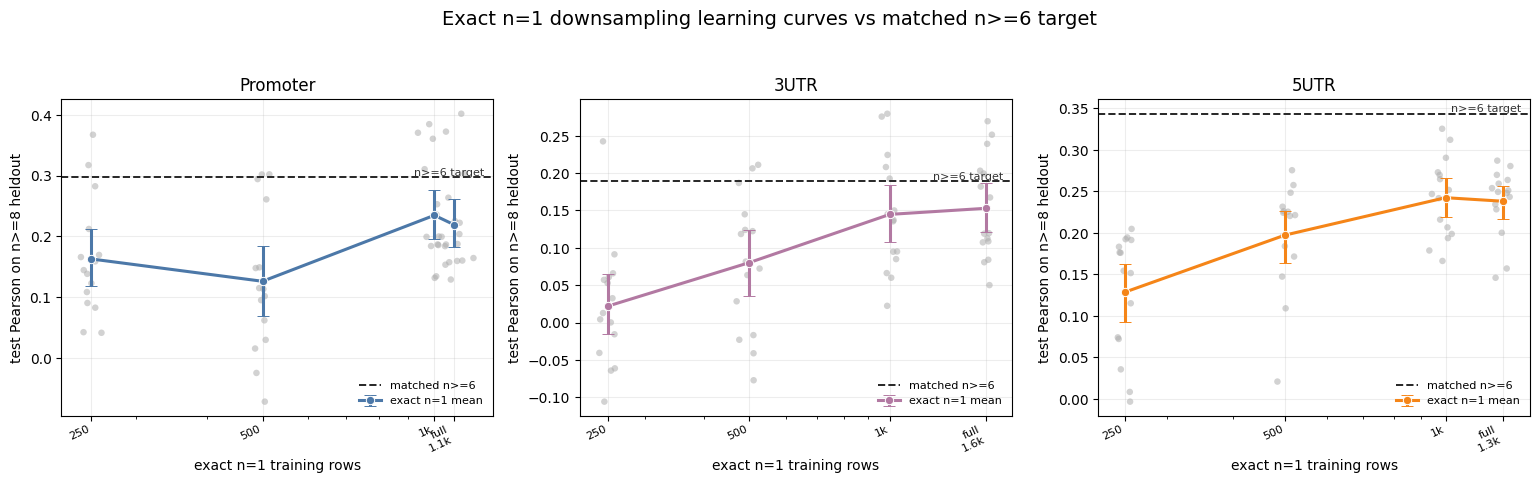

In [21]:

import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), sharey=False)
metric = 'test_pearson'
mean_col = f'{metric}_mean'
low_col = f'{metric}_ci_low'
high_col = f'{metric}_ci_high'

for ax, part in zip(axes, N1_DOWNSAMPLE_PARTS):
    color = PART_COLORS[part]
    raw = n1_curve_runs[n1_curve_runs['part'].astype(str).eq(part)].copy()
    summary = n1_curve_summary[n1_curve_summary['part'].astype(str).eq(part)].copy()
    summary = summary.set_index(summary['curve_size_label'].astype(str)).loc[N1_CURVE_ORDER].reset_index(drop=True)

    rng = np.random.default_rng(stable_seed('exact-n1-curve-jitter', part, metric))
    for size_label, g in raw.groupby('curve_size_label', observed=True):
        vals = pd.to_numeric(g[metric], errors='coerce')
        xs = pd.to_numeric(g['curve_train_rows'], errors='coerce')
        keep = vals.notna() & xs.notna()
        if not keep.any():
            continue
        jitter = np.exp(rng.normal(0, 0.025, size=int(keep.sum())))
        ax.scatter(
            xs.loc[keep].to_numpy(dtype=float) * jitter,
            vals.loc[keep].to_numpy(dtype=float),
            s=22,
            color='0.68',
            alpha=0.55,
            edgecolor='none',
            zorder=1,
        )

    x = summary['train_rows_median'].to_numpy(dtype=float)
    y = summary[mean_col].to_numpy(dtype=float)
    yerr = np.vstack([
        y - summary[low_col].to_numpy(dtype=float),
        summary[high_col].to_numpy(dtype=float) - y,
    ])
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        color=color,
        marker='o',
        markersize=6,
        markeredgecolor='white',
        markeredgewidth=0.7,
        lw=2.2,
        capsize=4,
        label='exact n=1 mean',
        zorder=3,
    )

    target = summary['matched_n_ge6_test_pearson_mean'].dropna()
    if not target.empty:
        target_value = float(target.iloc[0])
        ax.axhline(target_value, color='0.15', lw=1.4, ls='--', label='matched n>=6')
        ax.text(
            0.98,
            target_value,
            'n>=6 target',
            transform=ax.get_yaxis_transform(),
            ha='right',
            va='bottom',
            fontsize=8,
            color='0.20',
        )

    tick_rows = summary[['curve_size_label', 'train_rows_median']].drop_duplicates()
    tick_x = tick_rows['train_rows_median'].to_numpy(dtype=float)
    tick_labels = []
    for _, row in tick_rows.iterrows():
        label = str(row['curve_size_label'])
        rows = float(row['train_rows_median'])
        if label == 'full':
            tick_labels.append(f'full\n{rows / 1000:.1f}k')
        elif label == 'n1000':
            tick_labels.append('1k')
        else:
            tick_labels.append(N1_CURVE_LABELS.get(label, label))
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.FixedLocator(tick_x))
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(tick_labels))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', which='major', rotation=25, labelsize=8, pad=2)
    ax.tick_params(axis='x', which='minor', labelbottom=False)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    ax.set_xlabel('exact n=1 training rows')
    ax.set_title(part)
    ax.set_ylabel('test Pearson on n>=8 heldout')
    ax.grid(axis='both', alpha=0.22)
    ax.legend(frameon=False, fontsize=8, loc='lower right')

fig.suptitle('Exact n=1 downsampling learning curves vs matched n>=6 target', y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(N1_ANALYSIS_DIR / 'exact_n1_downsampling_test_pearson_vs_matched_n_ge6.png', dpi=180, bbox_inches='tight')
plt.show()


In [22]:

def exact_n1_marginal_gain_table(summary, metric='test_pearson_mean'):
    rows = []
    for part in N1_DOWNSAMPLE_PARTS:
        s = summary[summary['part'].astype(str).eq(part)].copy()
        s = s.set_index(s['curve_size_label'].astype(str)).loc[N1_CURVE_ORDER].reset_index(drop=True)
        for left, right in zip(N1_CURVE_ORDER[:-1], N1_CURVE_ORDER[1:]):
            a = s[s['curve_size_label'].astype(str).eq(left)].iloc[0]
            b = s[s['curve_size_label'].astype(str).eq(right)].iloc[0]
            row_delta = float(b['train_rows_median'] - a['train_rows_median'])
            metric_delta = float(b[metric] - a[metric])
            rows.append({
                'part': part,
                'from': N1_CURVE_LABELS[left],
                'to': N1_CURVE_LABELS[right],
                'from_train_rows': float(a['train_rows_median']),
                'to_train_rows': float(b['train_rows_median']),
                'additional_train_rows': row_delta,
                'test_pearson_from': float(a[metric]),
                'test_pearson_to': float(b[metric]),
                'test_pearson_gain': metric_delta,
                'test_pearson_gain_per_100_rows': metric_delta / row_delta * 100 if row_delta else np.nan,
            })
    return pd.DataFrame(rows)


def exact_n1_target_projection(summary):
    rows = []
    for part in N1_DOWNSAMPLE_PARTS:
        s = summary[summary['part'].astype(str).eq(part)].copy()
        s = s.set_index(s['curve_size_label'].astype(str)).loc[N1_CURVE_ORDER].reset_index(drop=True)
        target = float(s['matched_n_ge6_test_pearson_mean'].dropna().iloc[0])
        best_idx = s['test_pearson_mean'].astype(float).idxmax()
        best = s.loc[best_idx]
        full = s[s['curve_size_label'].astype(str).eq('full')].iloc[0]

        fit = s[['train_rows_median', 'test_pearson_mean']].dropna().copy()
        fit = fit[(fit['train_rows_median'] > 0) & np.isfinite(fit['test_pearson_mean'])]
        predicted_rows = np.nan
        additional_rows_vs_full = np.nan
        slope = np.nan
        note = 'not enough finite points for a log-linear projection'
        if target <= float(best['test_pearson_mean']):
            predicted_rows = float(best['train_rows_median'])
            additional_rows_vs_full = max(0.0, predicted_rows - float(full['train_rows_median']))
            note = 'target reached within observed exact n=1 curve'
        elif len(fit) >= 2:
            slope, intercept = np.polyfit(np.log(fit['train_rows_median'].to_numpy(dtype=float)), fit['test_pearson_mean'].to_numpy(dtype=float), 1)
            if slope > 0:
                predicted_rows = float(np.exp((target - intercept) / slope))
                additional_rows_vs_full = predicted_rows - float(full['train_rows_median'])
                note = 'log-linear extrapolation beyond observed exact n=1 range; treat as rough'
            else:
                note = 'not projected because the observed log-linear slope is non-positive'

        rows.append({
            'part': part,
            'matched_n_ge6_test_pearson_target': target,
            'best_observed_curve_point': N1_CURVE_LABELS.get(str(best['curve_size_label']), str(best['curve_size_label'])),
            'best_observed_train_rows': float(best['train_rows_median']),
            'best_observed_test_pearson': float(best['test_pearson_mean']),
            'remaining_gap_at_best': target - float(best['test_pearson_mean']),
            'full_exact_n1_train_rows': float(full['train_rows_median']),
            'full_exact_n1_test_pearson': float(full['test_pearson_mean']),
            'remaining_gap_at_full_exact_n1': target - float(full['test_pearson_mean']),
            'loglinear_slope_test_pearson_per_log_row': slope,
            'projected_exact_n1_rows_to_match_n_ge6': predicted_rows,
            'additional_exact_n1_rows_vs_full': additional_rows_vs_full,
            'projection_note': note,
        })
    return pd.DataFrame(rows)


n1_marginal_gain = exact_n1_marginal_gain_table(n1_curve_summary)
n1_target_projection = exact_n1_target_projection(n1_curve_summary)
n1_marginal_gain.to_csv(N1_ANALYSIS_DIR / 'exact_n1_marginal_gain_table.csv', index=False)
n1_target_projection.to_csv(N1_ANALYSIS_DIR / 'exact_n1_target_projection_vs_matched_n_ge6.csv', index=False)

display(Markdown('**Adjacent-point marginal gains along the exact n=1 curve**'))
display(n1_marginal_gain.round(4))
display(Markdown('**How far exact n=1 is from the matched n>=6 target**'))
display(n1_target_projection.round(4))


**Adjacent-point marginal gains along the exact n=1 curve**

,part,from,to,from_train_rows,to_train_rows,additional_train_rows,test_pearson_from,test_pearson_to,test_pearson_gain,test_pearson_gain_per_100_rows
0,Promoter,250,500,250.0,500.0,250.0,0.1630,0.1262,-0.0368,-0.0147
1,Promoter,500,"1,000",500.0,1000.0,500.0,0.1262,0.2346,0.1085,0.0217
2,Promoter,"1,000",full,1000.0,1082.0,82.0,0.2346,0.2194,-0.0153,-0.0186
3,3UTR,250,500,250.0,500.0,250.0,0.0222,0.0801,0.0579,0.0232
4,3UTR,500,"1,000",500.0,1000.0,500.0,0.0801,0.1448,0.0646,0.0129
5,3UTR,"1,000",full,1000.0,1610.0,610.0,0.1448,0.1529,0.0082,0.0013
6,5UTR,250,500,250.0,500.0,250.0,0.1284,0.1973,0.0688,0.0275
7,5UTR,500,"1,000",500.0,1000.0,500.0,0.1973,0.2423,0.0450,0.0090
8,5UTR,"1,000",full,1000.0,1279.0,279.0,0.2423,0.2381,-0.0042,-0.0015


**How far exact n=1 is from the matched n>=6 target**

,part,matched_n_ge6_test_pearson_target,best_observed_curve_point,best_observed_train_rows,best_observed_test_pearson,remaining_gap_at_best,full_exact_n1_train_rows,full_exact_n1_test_pearson,remaining_gap_at_full_exact_n1,loglinear_slope_test_pearson_per_log_row,projected_exact_n1_rows_to_match_n_ge6,additional_exact_n1_rows_vs_full,projection_note
0,Promoter,0.2971,"1,000",1000.0,0.2346,0.0624,1082.0,0.2194,0.0777,0.0537,4817.8133,3735.8133,log-linear extrapolation beyond observed exact...
1,3UTR,0.1888,full,1610.0,0.1529,0.0358,1610.0,0.1529,0.0358,0.0739,2225.3845,615.3845,log-linear extrapolation beyond observed exact...
2,5UTR,0.3434,"1,000",1000.0,0.2423,0.1011,1279.0,0.2381,0.1053,0.0698,4826.6713,3547.6713,log-linear extrapolation beyond observed exact...


In [23]:

projection_lines = []
for _, row in n1_target_projection.iterrows():
    projected = row['projected_exact_n1_rows_to_match_n_ge6']
    projected_text = 'not estimable from the observed curve'
    if pd.notna(projected):
        projected_text = f"about {projected:,.0f} exact n=1 training rows"
    projection_lines.append(
        f"- **{row['part']}:** best observed exact `n=1` point is `{row['best_observed_curve_point']}` "
        f"with test Pearson `{row['best_observed_test_pearson']:.3f}` vs matched `n>=6` target "
        f"`{row['matched_n_ge6_test_pearson_target']:.3f}`. "
        f"Current best gap is `{row['remaining_gap_at_best']:+.3f}`; rough target row estimate is {projected_text}."
    )

summary_md = """### Exact n=1 Downsampling Read

The cleaner wording here is **marginal gain along the exact `n=1` sample-size curve**. The adjacent gains quantify what the extra exact-`n=1` rows bought us between `250`, `500`, `1,000`, and the part-specific full pool. The projection table asks the experimental question of how many exact-`n=1` rows might be needed to match the matched `n>=6` endpoint, but that estimate is extrapolative whenever the target is above all observed exact-`n=1` points.

{bullets}

**Interpretation boundary:** these are exact `n=1` training pools evaluated on `n>=8` heldout variants. If full exact `n=1` remains below matched `n>=6`, the sample-count-to-match number is a modeling extrapolation, not an observed crossing.
""".format(bullets='\n'.join(projection_lines))

display(Markdown(summary_md))

print('Exact n=1 downsampling outputs:')
for path in sorted(N1_ANALYSIS_DIR.glob('*')):
    print(path.relative_to(ANALYSIS_DIR))


### Exact n=1 Downsampling Read

The cleaner wording here is **marginal gain along the exact `n=1` sample-size curve**. The adjacent gains quantify what the extra exact-`n=1` rows bought us between `250`, `500`, `1,000`, and the part-specific full pool. The projection table asks the experimental question of how many exact-`n=1` rows might be needed to match the matched `n>=6` endpoint, but that estimate is extrapolative whenever the target is above all observed exact-`n=1` points.

- **Promoter:** best observed exact `n=1` point is `1,000` with test Pearson `0.235` vs matched `n>=6` target `0.297`. Current best gap is `+0.062`; rough target row estimate is about 4,818 exact n=1 training rows.
- **3UTR:** best observed exact `n=1` point is `full` with test Pearson `0.153` vs matched `n>=6` target `0.189`. Current best gap is `+0.036`; rough target row estimate is about 2,225 exact n=1 training rows.
- **5UTR:** best observed exact `n=1` point is `1,000` with test Pearson `0.242` vs matched `n>=6` target `0.343`. Current best gap is `+0.101`; rough target row estimate is about 4,827 exact n=1 training rows.

**Interpretation boundary:** these are exact `n=1` training pools evaluated on `n>=8` heldout variants. If full exact `n=1` remains below matched `n>=6`, the sample-count-to-match number is a modeling extrapolation, not an observed crossing.


Exact n=1 downsampling outputs:
exact_n1_downsampling_learning_curve/exact_n1_downsampling_audit.csv
exact_n1_downsampling_learning_curve/exact_n1_downsampling_curve_summary.csv
exact_n1_downsampling_learning_curve/exact_n1_downsampling_joined_runs.csv
exact_n1_downsampling_learning_curve/exact_n1_downsampling_test_pearson_vs_matched_n_ge6.png
exact_n1_downsampling_learning_curve/exact_n1_marginal_gain_table.csv
exact_n1_downsampling_learning_curve/exact_n1_target_projection_vs_matched_n_ge6.csv


## Optional Per-Epoch History Export

The orchestrator logged train/val/test each epoch. The summary above uses best-checkpoint registry metrics. If you want per-epoch curve diagnostics for selected runs, enable the cell below. It reads local `.wandb` files through `src/learn/export_wandb_history.py` and writes TSV histories into this analysis directory.

In [24]:
EXPORT_LOCAL_WANDB_HISTORY = False

if EXPORT_LOCAL_WANDB_HISTORY:
    history_dir = ANALYSIS_DIR / 'wandb_history_exports'
    history_dir.mkdir(parents=True, exist_ok=True)
    run_ids = df['run_id'].dropna().astype(str).unique().tolist()
    cmd = [
        'python', str(REPO / 'src/learn/export_wandb_history.py'),
        '--wandb-dir', str(REPO / 'src/learn/wandb'),
        '--output-dir', str(history_dir),
    ]
    for run_id in run_ids:
        cmd.extend(['--run-id', run_id])
    print('Exporting histories for', len(run_ids), 'runs...')
    subprocess.run(cmd, check=True)
    display(pd.read_csv(history_dir / 'manifest.tsv', sep='\t'))
else:
    print('Set EXPORT_LOCAL_WANDB_HISTORY = True to export per-epoch train/val/test histories.')

Set EXPORT_LOCAL_WANDB_HISTORY = True to export per-epoch train/val/test histories.


## Files Written

The notebook writes reusable tables and plots to `tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_bin_matched_n1000_june2026/`.

In [25]:
written = sorted(p.relative_to(ANALYSIS_DIR) for p in ANALYSIS_DIR.glob('*'))
for path in written:
    print(path)

bin_summary.csv
config_bin_summary.csv
config_level_bin_profiles.png
exact_n1_downsampling_learning_curve
lib1_barcode_bin_n1_full_june2026__bin_summary.csv
lib1_barcode_bin_n1_full_june2026__joined_runs.csv
matched_n1000_test_pearson_by_bin.png
matched_n1000_val_pearson_by_bin.png
n1_available_train_rows_by_part.csv
objective_answer_table.csv
ordinal_test_pearson_trend_slices.csv
ordinal_test_pearson_trend_tests.csv
paired_test_delta_vs_ge6.csv
paired_test_delta_vs_ge6.png
paired_test_delta_vs_ge6_signflip_tests.csv
paired_train_delta_vs_ge6.csv
paired_val_delta_vs_ge6.csv
recomputed_bin_endpoint_summary.csv
split_seed_bin_summary.csv
test_winner_fraction_by_bin.png
test_winner_rates.csv
train_val_test_pearson_by_bin.png
weighted_loss_config_test_delta_seed_sem.png
weighted_loss_config_test_delta_seed_summary.csv
weighted_loss_delta_by_part_seed_sem.png
weighted_loss_delta_by_part_seed_summary.csv
weighted_loss_heldout_delta_by_part_seed_sem.png
weighted_loss_heldout_delta_by_part_see